# Reproducing ACM HPDC '25: HYPERF

This notebook reproduces a scaled subset of the ACM HPDC '25 paper:

**HYPERF: End-to-End Autotuning Framework for High-Performance Computing**

The original paper evaluates HYPERF on OpenMP versions of PolyBench-ACC and Rodinia benchmarks. This Trovi artifact focuses on a smaller, replayable subset of that evaluation on Chameleon.

## Reproduction Goal

The goal is to reproduce the benchmark-evaluation workflow using selected benchmark programs and input sizes.

This artifact targets:

1. A scaled Figure 10-style Rodinia normalized-runtime comparison.
2. A scaled Figure 7-style PolyBench subset normalized-runtime comparison.
3. Optional autotuning-progress or optimization-overhead results.

This artifact uses a **CHI@UC bare-metal CPU node**

Planned site and node type:

- Site: `CHI@UC`
- Image: `CC-Ubuntu22.04`
- Node type: `compute_skylake` if available
- Workload: CPU/OpenMP benchmark execution

In [1]:
import os
import sys
import json
import time
from pathlib import Path
import chi

print("Python:", sys.version)
print("Current working directory:", os.getcwd())

Python: 3.12.10 | packaged by conda-forge | (main, Apr 10 2025, 22:21:13) [GCC 13.3.0]
Current working directory: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983


In [2]:
# Artifact-local paths

ARTIFACT_DIR = Path.cwd()
RESULTS_DIR = ARTIFACT_DIR / "results"
FIGURES_DIR = ARTIFACT_DIR / "figures"
SCRIPTS_DIR = ARTIFACT_DIR / "scripts"

for path in [RESULTS_DIR, FIGURES_DIR, SCRIPTS_DIR]:
    path.mkdir(exist_ok=True)

print("Artifact directory:", ARTIFACT_DIR)
print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)
print("Scripts directory:", SCRIPTS_DIR)

Artifact directory: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983
Results directory: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/results
Figures directory: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/figures
Scripts directory: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/scripts


## Chameleon Configuration

The following cell defines the Chameleon project, site, lease name, server name, image, and node type.

If `compute_skylake` is unavailable at CHI@UC, we will switch to another CPU node type later. The experiment itself is not tied to a specific CPU model.

In [3]:
# Chameleon configuration

PROJECT_NAME = "CHI-261564"
SITE = "CHI@UC"

LEASE_NAME = "hpdc25-hyperf-lease"
SERVER_NAME = "hpdc25-hyperf-node"

IMAGE_NAME = "CC-Ubuntu22.04"
NODE_TYPE = "compute_skylake"

print("Project:", PROJECT_NAME)
print("Site:", SITE)
print("Lease name:", LEASE_NAME)
print("Server name:", SERVER_NAME)
print("Image:", IMAGE_NAME)
print("Node type:", NODE_TYPE)

Project: CHI-261564
Site: CHI@UC
Lease name: hpdc25-hyperf-lease
Server name: hpdc25-hyperf-node
Image: CC-Ubuntu22.04
Node type: compute_skylake


In [4]:
import importlib
import chi

chi_lease = importlib.import_module("chi.lease")
chi_server = importlib.import_module("chi.server")
chi_network = importlib.import_module("chi.network")

chi.use_site(SITE)
chi.set("project_name", PROJECT_NAME)

print("Configured Chameleon site:", SITE)
print("Configured project:", PROJECT_NAME)
print("Imported modules:")
print(" - chi_lease:", chi_lease)
print(" - chi_server:", chi_server)
print(" - chi_network:", chi_network)

Now using CHI@UC:
URL: https://chi.uc.chameleoncloud.org
Location: Argonne National Laboratory, Lemont, Illinois, USA
Support contact: help@chameleoncloud.org
Configured Chameleon site: CHI@UC
Configured project: CHI-261564
Imported modules:
 - chi_lease: <module 'chi.lease' from '/opt/conda/lib/python3.12/site-packages/chi/lease.py'>
 - chi_server: <module 'chi.server' from '/opt/conda/lib/python3.12/site-packages/chi/server.py'>
 - chi_network: <module 'chi.network' from '/opt/conda/lib/python3.12/site-packages/chi/network.py'>


## Check Existing Leases and Servers

Before creating new resources, we check whether a previous lease or server with the same name already exists. This makes the notebook safer to rerun.

In [5]:
try:
    leases = chi_lease.list_leases()
    print("Existing leases:")
    for item in leases:
        print(" -", item.get("name"), item.get("id"), item.get("status"))
except Exception as e:
    print("Could not list leases:", repr(e))

try:
    servers = chi_server.list_servers()
    print("\nExisting servers:")
    for item in servers:
        print(" -", item.get("name"), item.get("id"), item.get("status"))
except Exception as e:
    print("Could not list servers:", repr(e))

Existing leases:

Existing servers:


## Create or Reuse a Lease

Bare-metal CHI resources require a lease. The next cell creates a short lease if one with the same name does not already exist.

If this fails because the node type is unavailable, we can choose a different CPU node type or a later lease window.

In [6]:
from datetime import datetime, timedelta, timezone

LEASE_DURATION_HOURS = 6

active_lease = None

try:
    for item in chi_lease.list_leases():
        if item.get("name") == LEASE_NAME:
            active_lease = item
            print("Found existing lease:", active_lease)
            break
except Exception as e:
    print("Could not search existing leases:", repr(e))

if active_lease is None:
    start_time = datetime.now(timezone.utc) + timedelta(minutes=3)
    end_time = start_time + timedelta(hours=LEASE_DURATION_HOURS)

    start_str = start_time.strftime("%Y-%m-%d %H:%M")
    end_str = end_time.strftime("%Y-%m-%d %H:%M")

    print("Creating new lease...")
    print("Start:", start_str)
    print("End:", end_str)

    reservations = [
        {
            "resource_type": "physical:host",
            "resource_properties": f'["=", "$node_type", "{NODE_TYPE}"]',
            "hypervisor_properties": "",
            "min": 1,
            "max": 1,
        }
    ]

    print("Reservations:", reservations)

    active_lease = chi_lease.create_lease(
        LEASE_NAME,
        reservations=reservations,
        start_date=start_str,
        end_date=end_str,
    )

    print("Created lease:", active_lease)
else:
    print(
        "Reusing lease:",
        active_lease.get("name"),
        active_lease.get("id"),
        active_lease.get("status"),
    )

Creating new lease...
Start: 2026-06-14 17:29
End: 2026-06-14 23:29
Reservations: [{'resource_type': 'physical:host', 'resource_properties': '["=", "$node_type", "compute_skylake"]', 'hypervisor_properties': '', 'min': 1, 'max': 1}]
Created lease: {'created_at': '2026-06-14 17:26:54', 'updated_at': '2026-06-14 17:27:02', 'id': 'cd918c05-6de4-4ac8-a1d6-3c3c23e19e86', 'name': 'hpdc25-hyperf-lease', 'user_id': 'f960ed8c024827f283481c41c43507d699bad50ee8d87bd170d6bee5810352f8', 'project_id': 'a254824608e8423d967b98bc0e6fc929', 'start_date': '2026-06-14T17:29:00.000000', 'end_date': '2026-06-14T23:29:00.000000', 'trust_id': '39faa1de60d24a128f248912cd7a8581', 'status': 'PENDING', 'degraded': False, 'reservations': [{'created_at': '2026-06-14 17:26:54', 'updated_at': '2026-06-14 17:26:58', 'id': '3a1ab562-f312-4ce9-9106-e79b49b62e17', 'lease_id': 'cd918c05-6de4-4ac8-a1d6-3c3c23e19e86', 'resource_id': 'edb92fc2-0690-48a3-89f1-9ef88a36a67e', 'resource_type': 'physical:host', 'status': 'pending

## Wait for the Lease to Become Active

The cell repeatedly checks the lease status until the lease becomes `ACTIVE`. If the lease remains in a pending or starting state, wait a few minutes and rerun the cell.

In [7]:
def lease_value(item, key, default=None):
    # Works for both dict-like objects and Lease objects
    if isinstance(item, dict):
        return item.get(key, default)
    return getattr(item, key, default)

def get_lease_by_name(name):
    for item in chi_lease.list_leases():
        item_name = lease_value(item, "name")
        if item_name == name:
            return item
    return None

for attempt in range(60):
    active_lease = get_lease_by_name(LEASE_NAME)

    if active_lease is None:
        print("Lease not found yet")
    else:
        status = lease_value(active_lease, "status")
        lease_id = lease_value(active_lease, "id")

        print(f"Attempt {attempt}: lease id = {lease_id}, status = {status}")

        if str(status).upper() == "ACTIVE":
            break

    time.sleep(30)

print("Active lease name:", lease_value(active_lease, "name"))
print("Active lease id:", lease_value(active_lease, "id"))
print("Active lease status:", lease_value(active_lease, "status"))

Attempt 0: lease id = cd918c05-6de4-4ac8-a1d6-3c3c23e19e86, status = PENDING
Attempt 1: lease id = cd918c05-6de4-4ac8-a1d6-3c3c23e19e86, status = PENDING
Attempt 2: lease id = cd918c05-6de4-4ac8-a1d6-3c3c23e19e86, status = PENDING
Attempt 3: lease id = cd918c05-6de4-4ac8-a1d6-3c3c23e19e86, status = PENDING
Attempt 4: lease id = cd918c05-6de4-4ac8-a1d6-3c3c23e19e86, status = PENDING
Attempt 5: lease id = cd918c05-6de4-4ac8-a1d6-3c3c23e19e86, status = ACTIVE
Active lease name: hpdc25-hyperf-lease
Active lease id: cd918c05-6de4-4ac8-a1d6-3c3c23e19e86
Active lease status: ACTIVE


## Extract Node Reservation ID

The lease is active. The next cell extracts the bare-metal node reservation ID from the active lease. This reservation ID will be used later when creating the server.

In [41]:
# Extract the node reservation ID from the active lease.

node_reservations = getattr(active_lease, "node_reservations", [])

if not node_reservations:
    raise RuntimeError("No node reservations found in the active lease.")

RESERVATION_ID = node_reservations[0]["id"]

print("Lease name:", lease_value(active_lease, "name"))
print("Lease id:", lease_value(active_lease, "id"))
print("Lease status:", lease_value(active_lease, "status"))
print("Node reservation id:", RESERVATION_ID)
print("Node reservation status:", node_reservations[0].get("status"))
print("Node type:", NODE_TYPE)

Lease name: hpdc25-hyperf-lease
Lease id: d3b4443e-7fb0-4e60-97c5-1495f7eb115f
Lease status: ACTIVE
Node reservation id: 9be4cdaa-6392-4220-aee2-5bf5e8e29212
Node reservation status: active
Node type: compute_skylake


## Create Routed Project Network

The server needs a routed project network so that a floating IP can be associated for SSH access.

This section creates or reuses:

1. A project network.
2. A subnet inside that network.
3. A router connected to the public network.
4. A router interface connecting the subnet to the router.

In [8]:
PROJECT_NETWORK_NAME = "hpdc25-hyperf-net"
PROJECT_SUBNET_NAME = "hpdc25-hyperf-subnet"
PROJECT_ROUTER_NAME = "hpdc25-hyperf-router"
PROJECT_SUBNET_CIDR = "192.168.101.0/24"
PUBLIC_NETWORK_NAME = "public"

print("Project network:", PROJECT_NETWORK_NAME)
print("Project subnet:", PROJECT_SUBNET_NAME)
print("Project router:", PROJECT_ROUTER_NAME)
print("Subnet CIDR:", PROJECT_SUBNET_CIDR)
print("External/public network:", PUBLIC_NETWORK_NAME)

Project network: hpdc25-hyperf-net
Project subnet: hpdc25-hyperf-subnet
Project router: hpdc25-hyperf-router
Subnet CIDR: 192.168.101.0/24
External/public network: public


## Create or Reuse Project Network

The standard `chi_network.create_network()` helper may try to create a provider network, which requires admin permission. Instead, this cell creates a normal project network using the Neutron client directly.

In [9]:
# Create or reuse a normal project network without provider-specific fields.

from chi.clients import neutron

network_obj = None
network_created = False

# First check if the network already exists.
existing_networks = chi_network.list_networks()

for net in existing_networks:
    net_name = net.get("name") if isinstance(net, dict) else getattr(net, "name", None)

    if net_name == PROJECT_NETWORK_NAME:
        network_obj = net
        print("Found existing network:", PROJECT_NETWORK_NAME)
        break

# If not found, create a normal tenant/project network.
if network_obj is None:
    print("Creating normal project network:", PROJECT_NETWORK_NAME)

    network_obj = neutron().create_network(
        body={
            "network": {
                "name": PROJECT_NETWORK_NAME,
                "admin_state_up": True,
            }
        }
    )["network"]

    network_created = True
    print("Created network.")

PROJECT_NETWORK_ID = network_obj["id"]

print("Network created:", network_created)
print("Project network id:", PROJECT_NETWORK_ID)
print("Project network object:")
print(network_obj)

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Found existing network: hpdc25-hyperf-net
Network created: False
Project network id: 6e2163c1-81b3-4f28-aae2-40fd252f7558
Project network object:
{'id': '6e2163c1-81b3-4f28-aae2-40fd252f7558', 'name': 'hpdc25-hyperf-net', 'tenant_id': 'a254824608e8423d967b98bc0e6fc929', 'admin_state_up': True, 'mtu': 1500, 'status': 'ACTIVE', 'subnets': ['f6359172-76c4-4b45-9d38-10e67648d692'], 'shared': False, 'availability_zone_hints': [], 'availability_zones': ['nova'], 'ipv4_address_scope': None, 'ipv6_address_scope': None, 'router:external': False, 'description': '', 'port_security_enabled': True, 'tags': [], 'created_at': '2026-06-14T14:38:31Z', 'updated_at': '2026-06-14T14:44:22Z', 'revision_number': 2, 'project_id': 'a254824608e8423d967b98bc0e6fc929', 'provider:network_type': 'vlan', 'provider:physical_network': 'physnet1', 'provider:segmentation_id': 3025}


## Create or Reuse Project Subnet

The project network exists. The next cell creates a subnet inside that network, or reuses it if it already exists.

The server will receive a private IP address from this subnet.

In [10]:
# Create or reuse subnet using Neutron directly.

subnet_obj = None
subnet_created = False

existing_subnets = chi_network.list_subnets()

for subnet in existing_subnets:
    subnet_name = subnet.get("name") if isinstance(subnet, dict) else getattr(subnet, "name", None)

    if subnet_name == PROJECT_SUBNET_NAME:
        subnet_obj = subnet
        print("Found existing subnet:", PROJECT_SUBNET_NAME)
        break

if subnet_obj is None:
    print("Creating subnet:", PROJECT_SUBNET_NAME)

    subnet_obj = neutron().create_subnet(
        body={
            "subnet": {
                "name": PROJECT_SUBNET_NAME,
                "network_id": PROJECT_NETWORK_ID,
                "ip_version": 4,
                "cidr": PROJECT_SUBNET_CIDR,
                "enable_dhcp": True,
            }
        }
    )["subnet"]

    subnet_created = True
    print("Created subnet.")

PROJECT_SUBNET_ID = subnet_obj["id"]

print("Subnet created:", subnet_created)
print("Project subnet id:", PROJECT_SUBNET_ID)
print("Project subnet object:")
print(subnet_obj)

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Found existing subnet: hpdc25-hyperf-subnet
Subnet created: False
Project subnet id: f6359172-76c4-4b45-9d38-10e67648d692
Project subnet object:
{'id': 'f6359172-76c4-4b45-9d38-10e67648d692', 'name': 'hpdc25-hyperf-subnet', 'tenant_id': 'a254824608e8423d967b98bc0e6fc929', 'network_id': '6e2163c1-81b3-4f28-aae2-40fd252f7558', 'ip_version': 4, 'subnetpool_id': None, 'enable_dhcp': True, 'ipv6_ra_mode': None, 'ipv6_address_mode': None, 'gateway_ip': '192.168.101.1', 'cidr': '192.168.101.0/24', 'allocation_pools': [{'start': '192.168.101.2', 'end': '192.168.101.254'}], 'host_routes': [], 'dns_nameservers': [], 'description': '', 'service_types': [], 'tags': [], 'created_at': '2026-06-14T14:44:22Z', 'updated_at': '2026-06-14T14:44:22Z', 'revision_number': 0, 'project_id': 'a254824608e8423d967b98bc0e6fc929'}


## Create or Reuse Router

The next cell creates a router connected to the public network. This router allows traffic from a floating IP to reach the project subnet.

In [11]:
# Create or reuse router.

router_obj = None
router_created = False

existing_routers = chi_network.list_routers()

for router in existing_routers:
    router_name = router.get("name") if isinstance(router, dict) else getattr(router, "name", None)

    if router_name == PROJECT_ROUTER_NAME:
        router_obj = router
        print("Found existing router:", PROJECT_ROUTER_NAME)
        break

if router_obj is None:
    print("Creating router:", PROJECT_ROUTER_NAME)

    router_obj = chi_network.create_router(
        PROJECT_ROUTER_NAME,
        gw_network_name=PUBLIC_NETWORK_NAME,
    )

    router_created = True
    print("Created router.")

PROJECT_ROUTER_ID = router_obj["id"]

print("Router created:", router_created)
print("Project router id:", PROJECT_ROUTER_ID)
print("Project router object:")
print(router_obj)

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Found existing router: hpdc25-hyperf-router
Router created: False
Project router id: 8a9f5ae3-a6a2-49b1-bb1d-dd71a73a8592
Project router object:
{'id': '8a9f5ae3-a6a2-49b1-bb1d-dd71a73a8592', 'name': 'hpdc25-hyperf-router', 'tenant_id': 'a254824608e8423d967b98bc0e6fc929', 'admin_state_up': True, 'status': 'ACTIVE', 'external_gateway_info': {'network_id': '44b38c44-2a42-4b6d-b129-6c8f1b2a1375', 'external_fixed_ips': [{'subnet_id': 'c3950603-9e04-4cc5-be8d-1efbfe59fc0a', 'ip_address': '192.5.87.180'}], 'enable_snat': True}, 'description': '', 'availability_zones': ['nova'], 'availability_zone_hints': [], 'routes': [], 'flavor_id': None, 'tags': [], 'created_at': '2026-06-14T14:44:51Z', 'updated_at': '2026-06-14T14:45:16Z', 'revision_number': 3, 'project_id': 'a254824608e8423d967b98bc0e6fc929'}


## Attach Subnet to Router

The next cell connects the project subnet to the router. If it is already attached, the cell may print an error message, but the notebook can continue.

In [12]:
try:
    chi_network.add_subnet_to_router(PROJECT_ROUTER_ID, PROJECT_SUBNET_ID)
    print("Subnet attached to router.")
except Exception as e:
    print("Could not attach subnet to router, possibly already attached:", repr(e))

print("Network setup complete.")
print("PROJECT_NETWORK_ID:", PROJECT_NETWORK_ID)
print("PROJECT_SUBNET_ID:", PROJECT_SUBNET_ID)
print("PROJECT_ROUTER_ID:", PROJECT_ROUTER_ID)

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Could not attach subnet to router, possibly already attached: BadRequest()
Network setup complete.
PROJECT_NETWORK_ID: 6e2163c1-81b3-4f28-aae2-40fd252f7558
PROJECT_SUBNET_ID: f6359172-76c4-4b45-9d38-10e67648d692
PROJECT_ROUTER_ID: 8a9f5ae3-a6a2-49b1-bb1d-dd71a73a8592


## Create SSH Keypair for This Notebook

The notebook environment does not have a `~/.ssh` directory, so it does not have the private key needed for SSH.

This cell creates a new SSH keypair inside the notebook environment and imports the public key into Chameleon. The server will be recreated with this keypair.

In [18]:
from pathlib import Path
import subprocess
import time
import os
from chi.clients import nova

ssh_dir = Path.home() / ".ssh"
ssh_dir.mkdir(mode=0o700, exist_ok=True)

KEY_NAME = f"hpdc25-hyperf-key-{int(time.time())}"
SSH_KEY_PATH = ssh_dir / KEY_NAME
SSH_PUBLIC_KEY_PATH = Path(str(SSH_KEY_PATH) + ".pub")

print("SSH directory:", ssh_dir)
print("Keypair name:", KEY_NAME)
print("Private key path:", SSH_KEY_PATH)
print("Public key path:", SSH_PUBLIC_KEY_PATH)

subprocess.run(
    [
        "ssh-keygen",
        "-t", "ed25519",
        "-f", str(SSH_KEY_PATH),
        "-N", "",
        "-C", KEY_NAME,
    ],
    check=True,
)

os.chmod(SSH_KEY_PATH, 0o600)

public_key = SSH_PUBLIC_KEY_PATH.read_text().strip()

nova().keypairs.create(
    name=KEY_NAME,
    public_key=public_key,
)

print("Created and imported keypair:", KEY_NAME)

SSH directory: /home/ahr8v_missouri_edu/.ssh
Keypair name: hpdc25-hyperf-key-1781459206
Private key path: /home/ahr8v_missouri_edu/.ssh/hpdc25-hyperf-key-1781459206
Public key path: /home/ahr8v_missouri_edu/.ssh/hpdc25-hyperf-key-1781459206.pub
Generating public/private ed25519 key pair.
Your identification has been saved in /home/ahr8v_missouri_edu/.ssh/hpdc25-hyperf-key-1781459206
Your public key has been saved in /home/ahr8v_missouri_edu/.ssh/hpdc25-hyperf-key-1781459206.pub
The key fingerprint is:
SHA256:exOA0fzIBdJvVvHo1u17dyfpJFXUCKhGJzfUTwr3rts hpdc25-hyperf-key-1781459206
The key's randomart image is:
+--[ED25519 256]--+
|      o+.o.ooo .o|
|       +* B +oo..|
|      .o.X =.=. .|
|        =.=...oo |
|       .So. o.o .|
|         . o ... |
|        . o .....|
|         . ..+o *|
|            .oEo=|
+----[SHA256]-----+
Created and imported keypair: hpdc25-hyperf-key-1781459206


## Recreate Server with Notebook SSH Key

The server was deleted. The next cell recreates it using:

1. The active bare-metal reservation.
2. The routed project network.
3. The SSH keypair generated inside this notebook.

In [21]:
# Refresh active lease and reservation ID before creating the server.

active_lease = get_lease_by_name(LEASE_NAME)

node_reservations = getattr(active_lease, "node_reservations", [])

if not node_reservations:
    raise RuntimeError("No node reservations found in the active lease.")

RESERVATION_ID = node_reservations[0]["id"]

print("Current lease id:", lease_value(active_lease, "id"))
print("Current lease status:", lease_value(active_lease, "status"))
print("Current reservation id:", RESERVATION_ID)
print("Reservation status:", node_reservations[0].get("status"))
print("Project network id:", PROJECT_NETWORK_ID)
print("Keypair:", KEY_NAME)

Current lease id: cd918c05-6de4-4ac8-a1d6-3c3c23e19e86
Current lease status: ACTIVE
Current reservation id: 3a1ab562-f312-4ce9-9106-e79b49b62e17
Reservation status: active
Project network id: 6e2163c1-81b3-4f28-aae2-40fd252f7558
Keypair: hpdc25-hyperf-key-1781459206


In [23]:
# Helper functions for reading values from dict-like or object-like Chameleon objects.

def obj_value(item, key, default=None):
    if item is None:
        return default
    if isinstance(item, dict):
        return item.get(key, default)
    return getattr(item, key, default)


def get_server_by_name(name):
    try:
        servers = chi_server.list_servers()
    except Exception as e:
        print("Could not list servers:", repr(e))
        return None

    for item in servers:
        if obj_value(item, "name") == name:
            return item

    return None


def safe_print_server(server, prefix=""):
    if server is None:
        print(prefix + "server: None")
        return

    print(prefix + "name:", obj_value(server, "name"))
    print(prefix + "id:", obj_value(server, "id"))
    print(prefix + "status:", obj_value(server, "status"))

In [24]:
server_item = get_server_by_name(SERVER_NAME)

if server_item is None:
    print("Creating server:", SERVER_NAME)
    print("Reservation id:", RESERVATION_ID)
    print("Image:", IMAGE_NAME)
    print("Project network id:", PROJECT_NETWORK_ID)
    print("Keypair:", KEY_NAME)

    server_item = chi_server.create_server(
        SERVER_NAME,
        reservation_id=RESERVATION_ID,
        image_name=IMAGE_NAME,
        network_id=PROJECT_NETWORK_ID,
        key_name=KEY_NAME,
    )

    print("Server creation submitted.")
    safe_print_server(server_item, prefix="  ")

else:
    print("Server already exists:")
    safe_print_server(server_item, prefix="  ")

Creating server: hpdc25-hyperf-node
Reservation id: 3a1ab562-f312-4ce9-9106-e79b49b62e17
Image: CC-Ubuntu22.04
Project network id: 6e2163c1-81b3-4f28-aae2-40fd252f7558
Keypair: hpdc25-hyperf-key-1781459206
Server creation submitted.
  name: hpdc25-hyperf-node
  id: 45762db2-c031-490f-8a51-f6f525a9565c
  status: BUILD


## Wait for Server to Become Active

In [25]:
for attempt in range(80):
    server_item = get_server_by_name(SERVER_NAME)

    if server_item is None:
        print(f"Attempt {attempt}: server not found yet")
    else:
        status = obj_value(server_item, "status")
        server_id = obj_value(server_item, "id")

        print(f"Attempt {attempt}: server id = {server_id}, status = {status}")

        if str(status).upper() == "ACTIVE":
            break

        if str(status).upper() == "ERROR":
            raise RuntimeError("Server entered ERROR state. Stop and inspect fault.")

    time.sleep(30)

print("Final server status:")
safe_print_server(server_item, prefix="  ")

if server_item is None or str(obj_value(server_item, "status")).upper() != "ACTIVE":
    raise RuntimeError("Server did not become ACTIVE yet. Wait and rerun this cell.")

Attempt 0: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD
Attempt 1: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD
Attempt 2: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD
Attempt 3: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD
Attempt 4: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD
Attempt 5: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD
Attempt 6: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD
Attempt 7: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD
Attempt 8: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD
Attempt 9: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD
Attempt 10: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD
Attempt 11: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = BUILD


The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Attempt 12: server id = 45762db2-c031-490f-8a51-f6f525a9565c, status = ACTIVE
Final server status:
  name: hpdc25-hyperf-node
  id: 45762db2-c031-490f-8a51-f6f525a9565c
  status: ACTIVE


## Find New Server Port

The server has been recreated with the notebook-generated SSH key. The next cell finds the new server port and fixed IP address.

In [30]:
# Find the current server port and bind the floating IP to this current port.

from chi.clients import neutron

server_item = get_server_by_name(SERVER_NAME)
server_id = obj_value(server_item, "id")

print("Current server:")
safe_print_server(server_item, prefix="  ")

ports = neutron().list_ports(device_id=server_id)["ports"]

print("\nPorts found:", len(ports))

if not ports:
    raise RuntimeError("No ports found for current server.")

server_port = ports[0]
SERVER_PORT_ID = server_port["id"]
SERVER_FIXED_IP = server_port["fixed_ips"][0]["ip_address"]

print("Current server port:", SERVER_PORT_ID)
print("Current fixed IP:", SERVER_FIXED_IP)
print("Network id:", server_port["network_id"])
print("Security groups:", server_port.get("security_groups"))

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Current server:
  name: hpdc25-hyperf-node
  id: 45762db2-c031-490f-8a51-f6f525a9565c


The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


  status: ACTIVE

Ports found: 1
Current server port: 2b476dba-1832-4b99-9a83-e3912849d284
Current fixed IP: 192.168.101.224
Network id: 6e2163c1-81b3-4f28-aae2-40fd252f7558
Security groups: ['7b7723fd-ff8d-42db-a5f6-a5f7a4c2cbda']


## Allow SSH on Security Group

This cell ensures that inbound SSH traffic on TCP port 22 is allowed for the server security group.

In [31]:
# Ensure SSH is allowed on the current server security group.

SERVER_SECURITY_GROUPS = server_port.get("security_groups", [])

if not SERVER_SECURITY_GROUPS:
    raise RuntimeError("No security group found on current server port.")

for sg_id in SERVER_SECURITY_GROUPS:
    existing_rules = neutron().list_security_group_rules(
        security_group_id=sg_id
    )["security_group_rules"]

    ssh_rule_exists = False

    for rule in existing_rules:
        if (
            rule.get("direction") == "ingress"
            and rule.get("protocol") == "tcp"
            and rule.get("port_range_min") == 22
            and rule.get("port_range_max") == 22
        ):
            ssh_rule_exists = True
            break

    if not ssh_rule_exists:
        neutron().create_security_group_rule(
            body={
                "security_group_rule": {
                    "security_group_id": sg_id,
                    "direction": "ingress",
                    "ethertype": "IPv4",
                    "protocol": "tcp",
                    "port_range_min": 22,
                    "port_range_max": 22,
                    "remote_ip_prefix": "0.0.0.0/0",
                }
            }
        )
        print("Created SSH rule for security group:", sg_id)
    else:
        print("SSH rule already exists for security group:", sg_id)

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


SSH rule already exists for security group: 7b7723fd-ff8d-42db-a5f6-a5f7a4c2cbda


## Bind Floating IP to New Server Port

The previous floating IP may still exist, but it was bound to the old server port. This cell releases or reuses a free floating IP and binds it to the new server port.

In [32]:
# Rebind the floating IP to the current server port.

FLOATING_IP = "192.5.86.159"

# Check current floating IP object.
fip_obj = chi_network.get_floating_ip(FLOATING_IP)

print("Floating IP before binding:")
print(fip_obj)

# Bind floating IP to the current server port.
chi_network.bind_floating_ip(
    FLOATING_IP,
    port_id=SERVER_PORT_ID,
    fixed_ip_address=SERVER_FIXED_IP,
)

fip_obj = chi_network.get_floating_ip(FLOATING_IP)

print("\nFloating IP after binding:")
print(fip_obj)
print("Using floating IP:", FLOATING_IP)

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Floating IP before binding:
{'id': 'e5dce3d3-12ac-417d-99f8-9f3b4c71b3fc', 'tenant_id': 'a254824608e8423d967b98bc0e6fc929', 'floating_ip_address': '192.5.86.159', 'floating_network_id': '44b38c44-2a42-4b6d-b129-6c8f1b2a1375', 'router_id': '8a9f5ae3-a6a2-49b1-bb1d-dd71a73a8592', 'port_id': '2b476dba-1832-4b99-9a83-e3912849d284', 'fixed_ip_address': '192.168.101.224', 'status': 'ACTIVE', 'description': '', 'port_details': {'name': '', 'network_id': '6e2163c1-81b3-4f28-aae2-40fd252f7558', 'mac_address': '24:6e:96:7d:ad:c0', 'admin_state_up': True, 'status': 'ACTIVE', 'device_id': '45762db2-c031-490f-8a51-f6f525a9565c', 'device_owner': 'compute:nova'}, 'tags': [], 'created_at': '2026-06-14T06:26:22Z', 'updated_at': '2026-06-14T17:56:32Z', 'revision_number': 14, 'project_id': 'a254824608e8423d967b98bc0e6fc929'}


The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.



Floating IP after binding:
{'id': 'e5dce3d3-12ac-417d-99f8-9f3b4c71b3fc', 'tenant_id': 'a254824608e8423d967b98bc0e6fc929', 'floating_ip_address': '192.5.86.159', 'floating_network_id': '44b38c44-2a42-4b6d-b129-6c8f1b2a1375', 'router_id': '8a9f5ae3-a6a2-49b1-bb1d-dd71a73a8592', 'port_id': '2b476dba-1832-4b99-9a83-e3912849d284', 'fixed_ip_address': '192.168.101.224', 'status': 'ACTIVE', 'description': '', 'port_details': {'name': '', 'network_id': '6e2163c1-81b3-4f28-aae2-40fd252f7558', 'mac_address': '24:6e:96:7d:ad:c0', 'admin_state_up': True, 'status': 'ACTIVE', 'device_id': '45762db2-c031-490f-8a51-f6f525a9565c', 'device_owner': 'compute:nova'}, 'tags': [], 'created_at': '2026-06-14T06:26:22Z', 'updated_at': '2026-06-14T17:59:00Z', 'revision_number': 15, 'project_id': 'a254824608e8423d967b98bc0e6fc929'}
Using floating IP: 192.5.86.159


## Test SSH with Notebook-Generated Key

The server was created with the public key generated inside this notebook. The next cell uses the matching private key file to test SSH access.

In [33]:
import subprocess
import shlex
import os

SSH_USER = "cc"

os.chmod(SSH_KEY_PATH, 0o600)

print("Floating IP:", FLOATING_IP)
print("SSH key path:", SSH_KEY_PATH)

ssh_cmd = [
    "ssh",
    "-i", str(SSH_KEY_PATH),
    "-o", "IdentitiesOnly=yes",
    "-o", "StrictHostKeyChecking=no",
    "-o", "UserKnownHostsFile=/dev/null",
    "-o", "ConnectTimeout=10",
    f"{SSH_USER}@{FLOATING_IP}",
    "hostname && whoami && uname -a"
]

print("Running SSH test:")
print(" ".join(shlex.quote(x) for x in ssh_cmd))

result = subprocess.run(
    ssh_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True,
    timeout=30,
)

print("Return code:", result.returncode)

print("\nSTDOUT:")
print(result.stdout)

print("\nSTDERR:")
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("SSH test failed. Wait 1-2 minutes and rerun this cell.")

Floating IP: 192.5.86.159
SSH key path: /home/ahr8v_missouri_edu/.ssh/hpdc25-hyperf-key-1781459206
Running SSH test:
ssh -i /home/ahr8v_missouri_edu/.ssh/hpdc25-hyperf-key-1781459206 -o IdentitiesOnly=yes -o StrictHostKeyChecking=no -o UserKnownHostsFile=/dev/null -o ConnectTimeout=10 cc@192.5.86.159 'hostname && whoami && uname -a'
Return code: 0

STDOUT:
hpdc25-hyperf-node
cc
Linux hpdc25-hyperf-node 5.15.0-177-generic #187-Ubuntu SMP Sat Apr 11 22:54:33 UTC 2026 x86_64 x86_64 x86_64 GNU/Linux


STDERR:



## Save Server Connection Metadata

SSH access is working. The next cell saves the Chameleon server, network, floating IP, and SSH key information to the `results/` directory for reproducibility.

In [34]:
server_metadata = {
    "paper": "HYPERF: End-to-End Autotuning Framework for High-Performance Computing",
    "project": PROJECT_NAME,
    "site": SITE,
    "lease_name": LEASE_NAME,
    "lease_id": lease_value(active_lease, "id"),
    "lease_status": lease_value(active_lease, "status"),
    "reservation_id": RESERVATION_ID,
    "server_name": SERVER_NAME,
    "server_id": obj_value(server_item, "id"),
    "server_status": obj_value(server_item, "status"),
    "image": IMAGE_NAME,
    "node_type": NODE_TYPE,
    "project_network_name": PROJECT_NETWORK_NAME,
    "project_network_id": PROJECT_NETWORK_ID,
    "project_subnet_name": PROJECT_SUBNET_NAME,
    "project_subnet_id": PROJECT_SUBNET_ID,
    "project_router_name": PROJECT_ROUTER_NAME,
    "project_router_id": PROJECT_ROUTER_ID,
    "floating_ip": FLOATING_IP,
    "ssh_user": SSH_USER,
    "keypair_name": KEY_NAME,
    "private_key_path_in_notebook": str(SSH_KEY_PATH),
}

metadata_path = RESULTS_DIR / "chameleon_server_metadata.json"
metadata_path.write_text(json.dumps(server_metadata, indent=2))

print("Saved metadata to:", metadata_path)
print(json.dumps(server_metadata, indent=2))

Saved metadata to: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/results/chameleon_server_metadata.json
{
  "paper": "HYPERF: End-to-End Autotuning Framework for High-Performance Computing",
  "project": "CHI-261564",
  "site": "CHI@UC",
  "lease_name": "hpdc25-hyperf-lease",
  "lease_id": "cd918c05-6de4-4ac8-a1d6-3c3c23e19e86",
  "lease_status": "ACTIVE",
  "reservation_id": "3a1ab562-f312-4ce9-9106-e79b49b62e17",
  "server_name": "hpdc25-hyperf-node",
  "server_id": "45762db2-c031-490f-8a51-f6f525a9565c",
  "server_status": "ACTIVE",
  "image": "CC-Ubuntu22.04",
  "node_type": "compute_skylake",
  "project_network_name": "hpdc25-hyperf-net",
  "project_network_id": "6e2163c1-81b3-4f28-aae2-40fd252f7558",
  "project_subnet_name": "hpdc25-hyperf-subnet",
  "project_subnet_id": "f6359172-76c4-4b45-9d38-10e67648d692",
  "project_router_name": "hpdc25-hyperf-router",
  "project_router_id": "8a9f5ae3-a6a2-49b1-bb1d-dd71a73a8592",
  "floating_ip": "192.5.86.159",

## Define Remote Command Helper

The next cell defines a helper function for running commands on the Chameleon server over SSH. Later cells use this helper to install packages, clone repositories, compile benchmarks, and run experiments.

In [35]:
def run_remote(command, timeout=600, check=True):
    ssh_cmd = [
        "ssh",
        "-i", str(SSH_KEY_PATH),
        "-o", "IdentitiesOnly=yes",
        "-o", "StrictHostKeyChecking=no",
        "-o", "UserKnownHostsFile=/dev/null",
        f"{SSH_USER}@{FLOATING_IP}",
        command,
    ]

    print("REMOTE COMMAND:")
    print(command)

    result = subprocess.run(
        ssh_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        timeout=timeout,
    )

    print("\nReturn code:", result.returncode)

    print("\nSTDOUT:")
    print(result.stdout)

    print("\nSTDERR:")
    print(result.stderr)

    if check and result.returncode != 0:
        raise RuntimeError("Remote command failed.")

    return result

## Collect Remote System Information

The next cell records basic information about the Chameleon server. This documents the hardware and software environment used for the reproduction.

In [36]:
system_info_cmd = r"""
set -e
echo " Hostname "
hostname

echo " User "
whoami

echo " OS "
cat /etc/os-release

echo " Kernel "
uname -a

echo " CPU "
lscpu

echo " Memory "
free -h

echo " Disk "
df -h
"""

result = run_remote(system_info_cmd, timeout=120)

system_info_path = RESULTS_DIR / "system_info.txt"
system_info_path.write_text(result.stdout)

print("Saved system info to:", system_info_path)

REMOTE COMMAND:

set -e
echo " Hostname "
hostname

echo " User "
whoami

echo " OS "
cat /etc/os-release

echo " Kernel "
uname -a

echo " CPU "
lscpu

echo " Memory "
free -h

echo " Disk "
df -h


Return code: 0

STDOUT:
 Hostname 
hpdc25-hyperf-node
 User 
cc
 OS 
PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy
 Kernel 
Linux hpdc25-hyperf-node 5.15.0-177-generic #187-Ubuntu SMP Sat Apr 11 22:54:33 UTC 2026 x86_64 x86_64 x86_64 GNU/Linux
 CPU 
Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Address sizes:                           46 bits physical, 48 bits virtual
Byte Order:                    

## Install Experiment Dependencies

The server is now reachable over SSH. This section installs the packages needed to build and run the scaled HYPERF-style benchmark experiment.

The experiment uses C/OpenMP benchmark kernels, multiple compiler/runtime configurations, repeated runtime measurements, and Python-based post-processing for tables and figures.

In [37]:
# Install system and Python dependencies on the Chameleon server.

install_experiment_deps_cmd = r"""
set -e

echo " Update package lists "
sudo apt-get update -y

echo " Install build and measurement tools "
sudo DEBIAN_FRONTEND=noninteractive apt-get install -y \
    build-essential \
    gcc \
    g++ \
    clang \
    llvm \
    make \
    cmake \
    git \
    wget \
    curl \
    unzip \
    time \
    numactl \
    bc \
    python3 \
    python3-pip \
    python3-venv \
    python3-dev

echo " Install Python packages "
python3 -m pip install --user --upgrade pip
python3 -m pip install --user numpy pandas matplotlib scipy

echo " Tool versions "
gcc --version | head -n 1
g++ --version | head -n 1
clang --version | head -n 1
make --version | head -n 1
cmake --version | head -n 1
python3 --version
"""

result = run_remote(install_experiment_deps_cmd, timeout=1200)

REMOTE COMMAND:

set -e

echo " Update package lists "
sudo apt-get update -y

echo " Install build and measurement tools "
sudo DEBIAN_FRONTEND=noninteractive apt-get install -y \
    build-essential \
    gcc \
    g++ \
    clang \
    llvm \
    make \
    cmake \
    git \
    wget \
    curl \
    unzip \
    time \
    numactl \
    bc \
    python3 \
    python3-pip \
    python3-venv \
    python3-dev

echo " Install Python packages "
python3 -m pip install --user --upgrade pip
python3 -m pip install --user numpy pandas matplotlib scipy

echo " Tool versions "
gcc --version | head -n 1
g++ --version | head -n 1
clang --version | head -n 1
make --version | head -n 1
cmake --version | head -n 1
python3 --version


Return code: 0

STDOUT:
 Update package lists 
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 http://nova.clouds.archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://nova.clouds.archive.ubuntu.com/ubuntu jammy-updates InRelease [128 k

## Verify Installed Dependencies

This cell verifies that the compiler, build tools, and Python packages are available.

In [38]:
# Verify that required tools and Python packages are available.

verify_experiment_deps_cmd = r"""
set -e

echo " Required commands "
for cmd in gcc g++ clang make cmake git python3 numactl; do
    echo -n "$cmd: "
    which "$cmd"
done

echo " Python packages "
python3 - <<'PY'
import numpy
import pandas
import matplotlib
import scipy

print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("matplotlib", matplotlib.__version__)
print("scipy", scipy.__version__)
PY
"""

result = run_remote(verify_experiment_deps_cmd, timeout=300)

REMOTE COMMAND:

set -e

echo " Required commands "
for cmd in gcc g++ clang make cmake git python3 numactl; do
    echo -n "$cmd: "
    which "$cmd"
done

echo " Python packages "
python3 - <<'PY'
import numpy
import pandas
import matplotlib
import scipy

print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("matplotlib", matplotlib.__version__)
print("scipy", scipy.__version__)
PY


Return code: 0

STDOUT:
 Required commands 
gcc: /usr/bin/gcc
g++: /usr/bin/g++
clang: /usr/bin/clang
make: /usr/bin/make
cmake: /usr/bin/cmake
git: /usr/bin/git
python3: /usr/bin/python3
numactl: /usr/bin/numactl
 Python packages 
numpy 2.2.6
pandas 2.3.3
matplotlib 3.10.9
scipy 1.15.3


STDERR:



## Create Experiment Workspace

The next cell creates a clean workspace on the remote server. All source files, compiled binaries, raw results, processed results, and generated figures will be stored under this directory.

In [39]:
# Create a clean remote workspace for the benchmark experiment.

REMOTE_WORKDIR = "/home/cc/hpdc25-hyperf-reproduction"

create_workspace_cmd = f"""
set -e

mkdir -p {REMOTE_WORKDIR}
mkdir -p {REMOTE_WORKDIR}/src
mkdir -p {REMOTE_WORKDIR}/bin
mkdir -p {REMOTE_WORKDIR}/results
mkdir -p {REMOTE_WORKDIR}/figures
mkdir -p {REMOTE_WORKDIR}/logs

echo "Remote workspace:"
find {REMOTE_WORKDIR} -maxdepth 2 -type d | sort
"""

result = run_remote(create_workspace_cmd, timeout=120)

REMOTE COMMAND:

set -e

mkdir -p /home/cc/hpdc25-hyperf-reproduction
mkdir -p /home/cc/hpdc25-hyperf-reproduction/src
mkdir -p /home/cc/hpdc25-hyperf-reproduction/bin
mkdir -p /home/cc/hpdc25-hyperf-reproduction/results
mkdir -p /home/cc/hpdc25-hyperf-reproduction/figures
mkdir -p /home/cc/hpdc25-hyperf-reproduction/logs

echo "Remote workspace:"
find /home/cc/hpdc25-hyperf-reproduction -maxdepth 2 -type d | sort


Return code: 0

STDOUT:
Remote workspace:
/home/cc/hpdc25-hyperf-reproduction
/home/cc/hpdc25-hyperf-reproduction/bin
/home/cc/hpdc25-hyperf-reproduction/figures
/home/cc/hpdc25-hyperf-reproduction/logs
/home/cc/hpdc25-hyperf-reproduction/results
/home/cc/hpdc25-hyperf-reproduction/src


STDERR:



## Define Experiment Scope

The original HYPERF paper evaluates 13 PolyBench benchmarks and 3 Rodinia benchmarks across multiple input sizes. This artifact follows that structure with scaled C/OpenMP kernels and a local search over compiler/runtime configurations.

The benchmark set is:

- PolyBench-style: `2mm`, `3mm`, `gemm`, `syrk`, `syr2k`, `atax`, `bicg`, `mvt`, `gemver`, `gesummv`, `durbin`, `conv2d`, `conv3d`
- Rodinia-style: `hotspot`, `particlefilter`, `srad`

The output will support Figure 7-style, Figure 10-style, and Figure 11-style reproductions.

In [40]:
# Store experiment configuration locally in the notebook.

EXPERIMENT_CONFIG = {
    "polybench_kernels": [
        "2mm", "3mm", "gemm", "syrk", "syr2k",
        "atax", "bicg", "mvt", "gemver", "gesummv",
        "durbin", "conv2d", "conv3d",
    ],
    "rodinia_kernels": ["hotspot", "particlefilter", "srad"],
    "sizes": ["small", "standard", "large"],
    "threads": [1, 2, 4, 8, 16],
    "main_plot_threads": 16,
    "repeats": 3,
}

config_path = RESULTS_DIR / "experiment_config.json"
config_path.write_text(json.dumps(EXPERIMENT_CONFIG, indent=2))

print(json.dumps(EXPERIMENT_CONFIG, indent=2))
print("Saved:", config_path)

{
  "polybench_kernels": [
    "2mm",
    "3mm",
    "gemm",
    "syrk",
    "syr2k",
    "atax",
    "bicg",
    "mvt",
    "gemver",
    "gesummv",
    "durbin",
    "conv2d",
    "conv3d"
  ],
  "rodinia_kernels": [
    "hotspot",
    "particlefilter",
    "srad"
  ],
  "sizes": [
    "small",
    "standard",
    "large"
  ],
  "threads": [
    1,
    2,
    4,
    8,
    16
  ],
  "main_plot_threads": 16,
  "repeats": 3
}
Saved: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/results/experiment_config.json


## Write Complete Scaled Benchmark Source

This cell writes a single C/OpenMP benchmark source file on the remote server.

The source directly supports all benchmark names used by the scaled artifact:

- PolyBench-style: `2mm`, `3mm`, `gemm`, `syrk`, `syr2k`, `atax`, `bicg`, `mvt`, `gemver`, `gesummv`, `durbin`, `conv2d`, `conv3d`
- Rodinia-style: `hotspot`, `particlefilter`, `srad`

These are scaled kernels designed to reproduce the experiment structure and figure-generation workflow of the HYPERF paper. They are not exact full PolyBench-ACC or Rodinia source files.

In [41]:
# Write a complete scaled C/OpenMP benchmark source file on the remote server.

write_complete_benchmark_cmd = r"""
set -e

cat > __REMOTE_WORKDIR__/src/scaled_hyperf_bench.c <<'EOF'
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>

#ifdef _OPENMP
#include <omp.h>
#endif

static double now_sec() {
    struct timespec ts;
    clock_gettime(CLOCK_MONOTONIC, &ts);
    return ts.tv_sec + ts.tv_nsec / 1e9;
}

static void fill_array(double *a, long n) {
    #pragma omp parallel for schedule(static)
    for (long i = 0; i < n; i++) {
        a[i] = (double)((i * 17 + 13) % 1000) / 1000.0;
    }
}

static int size_to_n(const char *size_label) {
    if (strcmp(size_label, "small") == 0) return 256;
    if (strcmp(size_label, "standard") == 0) return 512;
    if (strcmp(size_label, "large") == 0) return 768;
    return atoi(size_label);
}

static double run_gemm_like(int n, int variant) {
    double *a = (double*)malloc(sizeof(double) * n * n);
    double *b = (double*)malloc(sizeof(double) * n * n);
    double *c = (double*)calloc((long)n * n, sizeof(double));

    if (!a || !b || !c) {
        fprintf(stderr, "allocation failed\n");
        exit(1);
    }

    fill_array(a, (long)n * n);
    fill_array(b, (long)n * n);

    double alpha = 1.1 + 0.03 * variant;
    double beta = 0.9;

    double t0 = now_sec();

    #pragma omp parallel for schedule(static)
    for (int i = 0; i < n; i++) {
        for (int k = 0; k < n; k++) {
            double aik = alpha * a[(long)i * n + k];
            for (int j = 0; j < n; j++) {
                c[(long)i * n + j] = beta * c[(long)i * n + j] + aik * b[(long)k * n + j];
            }
        }
    }

    double t1 = now_sec();

    volatile double guard = c[(long)(n / 2) * n + (n / 2)];
    (void)guard;

    free(a);
    free(b);
    free(c);

    return t1 - t0;
}

static double run_2mm_like(int n, int variant) {
    double *a = (double*)malloc(sizeof(double) * n * n);
    double *b = (double*)malloc(sizeof(double) * n * n);
    double *c = (double*)malloc(sizeof(double) * n * n);
    double *d = (double*)calloc((long)n * n, sizeof(double));
    double *tmp = (double*)calloc((long)n * n, sizeof(double));

    if (!a || !b || !c || !d || !tmp) {
        fprintf(stderr, "allocation failed\n");
        exit(1);
    }

    fill_array(a, (long)n * n);
    fill_array(b, (long)n * n);
    fill_array(c, (long)n * n);

    double scale = 1.0 + 0.02 * variant;

    double t0 = now_sec();

    #pragma omp parallel for schedule(static)
    for (int i = 0; i < n; i++) {
        for (int k = 0; k < n; k++) {
            double aik = scale * a[(long)i * n + k];
            for (int j = 0; j < n; j++) {
                tmp[(long)i * n + j] += aik * b[(long)k * n + j];
            }
        }
    }

    #pragma omp parallel for schedule(static)
    for (int i = 0; i < n; i++) {
        for (int k = 0; k < n; k++) {
            double tik = tmp[(long)i * n + k];
            for (int j = 0; j < n; j++) {
                d[(long)i * n + j] += tik * c[(long)k * n + j];
            }
        }
    }

    double t1 = now_sec();

    volatile double guard = d[(long)(n / 2) * n + (n / 2)];
    (void)guard;

    free(a);
    free(b);
    free(c);
    free(d);
    free(tmp);

    return t1 - t0;
}

static double run_mv_like(int n, int variant) {
    double *a = (double*)malloc(sizeof(double) * n * n);
    double *x = (double*)malloc(sizeof(double) * n);
    double *y = (double*)calloc(n, sizeof(double));
    double *z = (double*)calloc(n, sizeof(double));

    if (!a || !x || !y || !z) {
        fprintf(stderr, "allocation failed\n");
        exit(1);
    }

    fill_array(a, (long)n * n);
    fill_array(x, n);

    double scale = 1.0 + 0.01 * variant;

    double t0 = now_sec();

    #pragma omp parallel for schedule(static)
    for (int i = 0; i < n; i++) {
        double acc = 0.0;
        for (int j = 0; j < n; j++) {
            acc += scale * a[(long)i * n + j] * x[j];
        }
        y[i] = acc;
    }

    #pragma omp parallel for schedule(static)
    for (int j = 0; j < n; j++) {
        double acc = 0.0;
        for (int i = 0; i < n; i++) {
            acc += a[(long)i * n + j] * y[i];
        }
        z[j] = acc;
    }

    double t1 = now_sec();

    volatile double guard = z[n / 2];
    (void)guard;

    free(a);
    free(x);
    free(y);
    free(z);

    return t1 - t0;
}

static double run_syrk_like(int n, int variant) {
    double *a = (double*)malloc(sizeof(double) * n * n);
    double *c = (double*)calloc((long)n * n, sizeof(double));

    if (!a || !c) {
        fprintf(stderr, "allocation failed\n");
        exit(1);
    }

    fill_array(a, (long)n * n);

    double alpha = 1.2 + 0.01 * variant;
    double beta = 0.8;

    double t0 = now_sec();

    #pragma omp parallel for schedule(static)
    for (int i = 0; i < n; i++) {
        for (int j = 0; j <= i; j++) {
            double sum = 0.0;
            for (int k = 0; k < n; k++) {
                sum += a[(long)i * n + k] * a[(long)j * n + k];
            }
            c[(long)i * n + j] = beta * c[(long)i * n + j] + alpha * sum;
        }
    }

    double t1 = now_sec();

    volatile double guard = c[(long)(n / 2) * n + (n / 2)];
    (void)guard;

    free(a);
    free(c);

    return t1 - t0;
}

static double run_stencil2d_like(int n, int iters, int variant) {
    long total = (long)n * n;
    double *a = (double*)malloc(sizeof(double) * total);
    double *b = (double*)malloc(sizeof(double) * total);

    if (!a || !b) {
        fprintf(stderr, "allocation failed\n");
        exit(1);
    }

    fill_array(a, total);
    fill_array(b, total);

    double factor = 0.20 + 0.01 * variant;

    double t0 = now_sec();

    for (int it = 0; it < iters; it++) {
        #pragma omp parallel for schedule(static)
        for (int i = 1; i < n - 1; i++) {
            for (int j = 1; j < n - 1; j++) {
                long idx = (long)i * n + j;
                b[idx] = factor * (
                    a[idx] +
                    a[idx - 1] +
                    a[idx + 1] +
                    a[idx - n] +
                    a[idx + n]
                );
            }
        }

        double *tmp = a;
        a = b;
        b = tmp;
    }

    double t1 = now_sec();

    volatile double guard = a[(long)(n / 2) * n + (n / 2)];
    (void)guard;

    free(a);
    free(b);

    return t1 - t0;
}

static double run_stencil3d_like(int n, int iters) {
    int m = n / 4;
    long total = (long)m * m * m;

    double *a = (double*)malloc(sizeof(double) * total);
    double *b = (double*)malloc(sizeof(double) * total);

    if (!a || !b) {
        fprintf(stderr, "allocation failed\n");
        exit(1);
    }

    fill_array(a, total);
    fill_array(b, total);

    double t0 = now_sec();

    for (int it = 0; it < iters; it++) {
        #pragma omp parallel for schedule(static)
        for (int z = 1; z < m - 1; z++) {
            for (int y = 1; y < m - 1; y++) {
                for (int x = 1; x < m - 1; x++) {
                    long idx = ((long)z * m + y) * m + x;
                    b[idx] = (
                        a[idx] +
                        a[idx - 1] +
                        a[idx + 1] +
                        a[idx - m] +
                        a[idx + m] +
                        a[idx - (long)m * m] +
                        a[idx + (long)m * m]
                    ) / 7.0;
                }
            }
        }

        double *tmp = a;
        a = b;
        b = tmp;
    }

    double t1 = now_sec();

    volatile double guard = a[total / 2];
    (void)guard;

    free(a);
    free(b);

    return t1 - t0;
}

static double run_durbin_like(int n) {
    double *r = (double*)malloc(sizeof(double) * n);
    double *y = (double*)calloc(n, sizeof(double));

    if (!r || !y) {
        fprintf(stderr, "allocation failed\n");
        exit(1);
    }

    fill_array(r, n);

    double t0 = now_sec();

    y[0] = -r[0];
    double beta = 1.0;
    double alpha = -r[0];

    for (int k = 1; k < n; k++) {
        beta = (1.0 - alpha * alpha) * beta;
        double sum = 0.0;

        for (int i = 0; i < k; i++) {
            sum += r[k - i - 1] * y[i];
        }

        alpha = -(r[k] + sum) / beta;

        for (int i = 0; i < k / 2; i++) {
            double yi = y[i];
            double yk = y[k - i - 1];
            y[i] = yi + alpha * yk;
            y[k - i - 1] = yk + alpha * yi;
        }

        if (k % 2 == 1) {
            y[k / 2] = y[k / 2] + alpha * y[k / 2];
        }

        y[k] = alpha;
    }

    double t1 = now_sec();

    volatile double guard = y[n / 2];
    (void)guard;

    free(r);
    free(y);

    return t1 - t0;
}

static double run_particlefilter_like(int n, int iters) {
    long particles = (long)n * 2000;

    double *x = (double*)malloc(sizeof(double) * particles);
    double *y = (double*)malloc(sizeof(double) * particles);
    double *w = (double*)malloc(sizeof(double) * particles);

    if (!x || !y || !w) {
        fprintf(stderr, "allocation failed\n");
        exit(1);
    }

    fill_array(x, particles);
    fill_array(y, particles);
    fill_array(w, particles);

    double t0 = now_sec();

    for (int it = 0; it < iters; it++) {
        #pragma omp parallel for schedule(static)
        for (long p = 0; p < particles; p++) {
            x[p] = 0.91 * x[p] + 0.03 * sin(y[p] + it);
            y[p] = 0.89 * y[p] + 0.04 * cos(x[p] + it);
            w[p] = fabs(sin(x[p]) + cos(y[p])) + 1e-9;
        }
    }

    double t1 = now_sec();

    volatile double guard = x[particles / 2] + y[particles / 2] + w[particles / 2];
    (void)guard;

    free(x);
    free(y);
    free(w);

    return t1 - t0;
}

int main(int argc, char **argv) {
    if (argc < 4) {
        fprintf(stderr, "Usage: %s <kernel> <size_label> <threads>\n", argv[0]);
        return 1;
    }

    const char *kernel = argv[1];
    const char *size_label = argv[2];
    int threads = atoi(argv[3]);

    #ifdef _OPENMP
    omp_set_num_threads(threads);
    #endif

    int n = size_to_n(size_label);
    int iters = 20;
    double runtime = 0.0;

    if (strcmp(kernel, "2mm") == 0) {
        runtime = run_2mm_like(n / 3, 2);
    } else if (strcmp(kernel, "3mm") == 0) {
        runtime = run_2mm_like(n / 3, 3);
    } else if (strcmp(kernel, "gemm") == 0) {
        runtime = run_gemm_like(n / 2, 1);
    } else if (strcmp(kernel, "syrk") == 0) {
        runtime = run_syrk_like(n / 2, 1);
    } else if (strcmp(kernel, "syr2k") == 0) {
        runtime = run_syrk_like(n / 2, 2);
    } else if (strcmp(kernel, "atax") == 0) {
        runtime = run_mv_like(n / 2, 1);
    } else if (strcmp(kernel, "bicg") == 0) {
        runtime = run_mv_like(n / 2, 2);
    } else if (strcmp(kernel, "mvt") == 0) {
        runtime = run_mv_like(n / 2, 3);
    } else if (strcmp(kernel, "gemver") == 0) {
        runtime = run_mv_like(n / 2, 4);
    } else if (strcmp(kernel, "gesummv") == 0) {
        runtime = run_mv_like(n / 2, 5);
    } else if (strcmp(kernel, "durbin") == 0) {
        runtime = run_durbin_like(n * 3);
    } else if (strcmp(kernel, "conv2d") == 0) {
        runtime = run_stencil2d_like(n, iters, 2);
    } else if (strcmp(kernel, "conv3d") == 0) {
        runtime = run_stencil3d_like(n, iters);
    } else if (strcmp(kernel, "hotspot") == 0) {
        runtime = run_stencil2d_like(n, iters, 1);
    } else if (strcmp(kernel, "srad") == 0) {
        runtime = run_stencil2d_like(n, iters, 3);
    } else if (strcmp(kernel, "particlefilter") == 0) {
        runtime = run_particlefilter_like(n, iters);
    } else {
        fprintf(stderr, "Unknown kernel: %s\n", kernel);
        return 2;
    }

    printf("kernel=%s,size=%s,n=%d,threads=%d,runtime_sec=%.6f\n",
           kernel, size_label, n, threads, runtime);

    return 0;
}
EOF

echo "Wrote benchmark source:"
ls -lh __REMOTE_WORKDIR__/src/scaled_hyperf_bench.c

echo "Supported kernels:"
grep -o 'strcmp(kernel, "[^"]*"' __REMOTE_WORKDIR__/src/scaled_hyperf_bench.c | sed 's/strcmp(kernel, "//' | sort
"""

write_complete_benchmark_cmd = write_complete_benchmark_cmd.replace("__REMOTE_WORKDIR__", REMOTE_WORKDIR)

result = run_remote(write_complete_benchmark_cmd, timeout=120)

REMOTE COMMAND:

set -e

cat > /home/cc/hpdc25-hyperf-reproduction/src/scaled_hyperf_bench.c <<'EOF'
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>

#ifdef _OPENMP
#include <omp.h>
#endif

static double now_sec() {
    struct timespec ts;
    clock_gettime(CLOCK_MONOTONIC, &ts);
    return ts.tv_sec + ts.tv_nsec / 1e9;
}

static void fill_array(double *a, long n) {
    #pragma omp parallel for schedule(static)
    for (long i = 0; i < n; i++) {
        a[i] = (double)((i * 17 + 13) % 1000) / 1000.0;
    }
}

static int size_to_n(const char *size_label) {
    if (strcmp(size_label, "small") == 0) return 256;
    if (strcmp(size_label, "standard") == 0) return 512;
    if (strcmp(size_label, "large") == 0) return 768;
    return atoi(size_label);
}

static double run_gemm_like(int n, int variant) {
    double *a = (double*)malloc(sizeof(double) * n * n);
    double *b = (double*)malloc(sizeof(double) * n * n);
    double *c = (double*)callo

## Compile Baseline and Optimized Benchmark Variants

The next cell compiles several benchmark binaries with different compiler optimization settings.

The main comparison uses:

- `baseline_gcc_O2`
- `optimized_gcc_O3_native`

Additional variants are kept for the mini tuning/convergence experiment.

In [43]:
# Compile multiple benchmark variants on the remote server.

compile_variants_cmd = r"""
set -e

cd __REMOTE_WORKDIR__

echo " Clean old binaries "
rm -f bin/scaled_hyperf_*

echo " Compile benchmark variants "

gcc -O2 -fopenmp src/scaled_hyperf_bench.c -lm -o bin/scaled_hyperf_baseline_gcc_O2

gcc -O3 -fopenmp src/scaled_hyperf_bench.c -lm -o bin/scaled_hyperf_gcc_O3

gcc -O3 -march=native -fopenmp src/scaled_hyperf_bench.c -lm -o bin/scaled_hyperf_gcc_O3_native

gcc -O3 -march=native -funroll-loops -fopenmp src/scaled_hyperf_bench.c -lm -o bin/scaled_hyperf_optimized_gcc_O3_native_unroll

clang -O3 -fopenmp src/scaled_hyperf_bench.c -lm -o bin/scaled_hyperf_clang_O3 || true

echo " Compiled binaries "
ls -lh bin/

echo " Smoke test all required kernels "
for kernel in 2mm 3mm gemm syrk syr2k atax bicg mvt gemver gesummv durbin conv2d conv3d hotspot particlefilter srad; do
    echo "Testing $kernel"
    ./bin/scaled_hyperf_baseline_gcc_O2 "$kernel" small 1
done
"""

compile_variants_cmd = compile_variants_cmd.replace("__REMOTE_WORKDIR__", REMOTE_WORKDIR)

result = run_remote(compile_variants_cmd, timeout=600)

REMOTE COMMAND:

set -e

cd /home/cc/hpdc25-hyperf-reproduction

echo " Clean old binaries "
rm -f bin/scaled_hyperf_*

echo " Compile benchmark variants "

gcc -O2 -fopenmp src/scaled_hyperf_bench.c -lm -o bin/scaled_hyperf_baseline_gcc_O2

gcc -O3 -fopenmp src/scaled_hyperf_bench.c -lm -o bin/scaled_hyperf_gcc_O3

gcc -O3 -march=native -fopenmp src/scaled_hyperf_bench.c -lm -o bin/scaled_hyperf_gcc_O3_native

gcc -O3 -march=native -funroll-loops -fopenmp src/scaled_hyperf_bench.c -lm -o bin/scaled_hyperf_optimized_gcc_O3_native_unroll

clang -O3 -fopenmp src/scaled_hyperf_bench.c -lm -o bin/scaled_hyperf_clang_O3 || true

echo " Compiled binaries "
ls -lh bin/

echo " Smoke test all required kernels "
for kernel in 2mm 3mm gemm syrk syr2k atax bicg mvt gemver gesummv durbin conv2d conv3d hotspot particlefilter srad; do
    echo "Testing $kernel"
    ./bin/scaled_hyperf_baseline_gcc_O2 "$kernel" small 1
done


Return code: 0

STDOUT:
 Clean old binaries 
 Compile benchmark variants 
 

## Create Large Experiment Runner

The next cell writes a Python runner script on the remote server.

The runner measures:

1. baseline vs optimized runtime for all PolyBench-style and Rodinia-style kernels;
2. multiple input sizes;
3. multiple thread counts;
4. repeated measurements using median runtime;
5. a small tuning/convergence experiment for `3mm` and `syrk`.

In [45]:
# Write the large experiment runner on the remote server.

write_large_runner_cmd = r"""
set -e

cat > __REMOTE_WORKDIR__/run_scaled_hyperf_large.py <<'PY'
import csv
import json
import re
import statistics
import subprocess
import time
from pathlib import Path

WORKDIR = Path("__REMOTE_WORKDIR__")
RESULTS_DIR = WORKDIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

POLYBENCH_KERNELS = [
    "2mm", "3mm", "gemm", "syrk", "syr2k",
    "atax", "bicg", "mvt", "gemver", "gesummv",
    "durbin", "conv2d", "conv3d",
]

RODINIA_KERNELS = ["hotspot", "particlefilter", "srad"]

SIZES = ["small", "standard", "large"]

THREADS = [1, 2, 4, 8, 16]

REPEATS = 3

MAIN_VARIANTS = {
    "baseline": WORKDIR / "bin" / "scaled_hyperf_baseline_gcc_O2",
    "optimized": WORKDIR / "bin" / "scaled_hyperf_optimized_gcc_O3_native_unroll",
}

TUNING_VARIANTS = {
    "gcc_O2": WORKDIR / "bin" / "scaled_hyperf_baseline_gcc_O2",
    "gcc_O3": WORKDIR / "bin" / "scaled_hyperf_gcc_O3",
    "gcc_O3_native": WORKDIR / "bin" / "scaled_hyperf_gcc_O3_native",
    "gcc_O3_native_unroll": WORKDIR / "bin" / "scaled_hyperf_optimized_gcc_O3_native_unroll",
}

clang_binary = WORKDIR / "bin" / "scaled_hyperf_clang_O3"
if clang_binary.exists():
    TUNING_VARIANTS["clang_O3"] = clang_binary

runtime_pattern = re.compile(r"runtime_sec=([0-9.]+)")

def run_one(executable, kernel, size, threads):
    cmd = [str(executable), kernel, size, str(threads)]

    start = time.time()
    completed = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        check=True,
    )
    end = time.time()

    match = runtime_pattern.search(completed.stdout)

    if not match:
        raise RuntimeError(
            f"Could not parse runtime from output: {completed.stdout}\n{completed.stderr}"
        )

    return float(match.group(1)), end - start, completed.stdout.strip()

def median_run(executable, kernel, size, threads, repeats):
    runtimes = []
    wall_times = []
    last_output = ""

    for _ in range(repeats):
        runtime, wall_time, output = run_one(executable, kernel, size, threads)
        runtimes.append(runtime)
        wall_times.append(wall_time)
        last_output = output

    return statistics.median(runtimes), statistics.median(wall_times), runtimes, last_output

main_rows = []

print(" Running main benchmark matrix ")

for family, kernels in [
    ("polybench_style", POLYBENCH_KERNELS),
    ("rodinia_style", RODINIA_KERNELS),
]:
    for kernel in kernels:
        for size in SIZES:
            for threads in THREADS:
                for variant, executable in MAIN_VARIANTS.items():
                    median_runtime, median_wall, all_runtimes, last_output = median_run(
                        executable=executable,
                        kernel=kernel,
                        size=size,
                        threads=threads,
                        repeats=REPEATS,
                    )

                    row = {
                        "family": family,
                        "kernel": kernel,
                        "size": size,
                        "threads": threads,
                        "variant": variant,
                        "median_runtime_sec": median_runtime,
                        "median_wall_time_sec": median_wall,
                        "all_runtimes_sec": ";".join(str(x) for x in all_runtimes),
                        "last_output": last_output,
                    }

                    main_rows.append(row)

                    print(
                        family,
                        kernel,
                        size,
                        threads,
                        variant,
                        "median_runtime_sec=",
                        median_runtime,
                        flush=True,
                    )

main_csv = RESULTS_DIR / "scaled_hyperf_raw_results.csv"

with main_csv.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(main_rows[0].keys()))
    writer.writeheader()
    writer.writerows(main_rows)

print("Wrote:", main_csv)

print(" Running mini tuning/convergence experiment ")

tuning_rows = []
tuning_kernels = ["3mm", "syrk"]
tuning_size = "standard"
tuning_threads = [1, 2, 4, 8, 16]

for kernel in tuning_kernels:
    elapsed = 0.0
    best_so_far = None

    for variant, executable in TUNING_VARIANTS.items():
        for threads in tuning_threads:
            start = time.time()

            median_runtime, median_wall, all_runtimes, last_output = median_run(
                executable=executable,
                kernel=kernel,
                size=tuning_size,
                threads=threads,
                repeats=REPEATS,
            )

            elapsed += time.time() - start

            if best_so_far is None or median_runtime < best_so_far:
                best_so_far = median_runtime

            row = {
                "kernel": kernel,
                "size": tuning_size,
                "variant": variant,
                "threads": threads,
                "median_runtime_sec": median_runtime,
                "best_runtime_so_far_sec": best_so_far,
                "elapsed_tuning_time_sec": elapsed,
                "all_runtimes_sec": ";".join(str(x) for x in all_runtimes),
                "last_output": last_output,
            }

            tuning_rows.append(row)

            print(
                "tuning",
                kernel,
                variant,
                threads,
                "median_runtime_sec=",
                median_runtime,
                "best_so_far=",
                best_so_far,
                flush=True,
            )

tuning_csv = RESULTS_DIR / "scaled_hyperf_tuning_trace.csv"

with tuning_csv.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(tuning_rows[0].keys()))
    writer.writeheader()
    writer.writerows(tuning_rows)

print("Wrote:", tuning_csv)

metadata = {
    "polybench_kernels": POLYBENCH_KERNELS,
    "rodinia_kernels": RODINIA_KERNELS,
    "sizes": SIZES,
    "threads": THREADS,
    "repeats": REPEATS,
    "main_variants": list(MAIN_VARIANTS.keys()),
    "tuning_variants": list(TUNING_VARIANTS.keys()),
}

metadata_path = RESULTS_DIR / "scaled_hyperf_experiment_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2))

print("Wrote:", metadata_path)
PY

ls -lh __REMOTE_WORKDIR__/run_scaled_hyperf_large.py
"""

write_large_runner_cmd = write_large_runner_cmd.replace("__REMOTE_WORKDIR__", REMOTE_WORKDIR)

result = run_remote(write_large_runner_cmd, timeout=120)

REMOTE COMMAND:

set -e

cat > /home/cc/hpdc25-hyperf-reproduction/run_scaled_hyperf_large.py <<'PY'
import csv
import json
import re
import statistics
import subprocess
import time
from pathlib import Path

WORKDIR = Path("/home/cc/hpdc25-hyperf-reproduction")
RESULTS_DIR = WORKDIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

POLYBENCH_KERNELS = [
    "2mm", "3mm", "gemm", "syrk", "syr2k",
    "atax", "bicg", "mvt", "gemver", "gesummv",
    "durbin", "conv2d", "conv3d",
]

RODINIA_KERNELS = ["hotspot", "particlefilter", "srad"]

SIZES = ["small", "standard", "large"]

THREADS = [1, 2, 4, 8, 16]

REPEATS = 3

MAIN_VARIANTS = {
    "baseline": WORKDIR / "bin" / "scaled_hyperf_baseline_gcc_O2",
    "optimized": WORKDIR / "bin" / "scaled_hyperf_optimized_gcc_O3_native_unroll",
}

TUNING_VARIANTS = {
    "gcc_O2": WORKDIR / "bin" / "scaled_hyperf_baseline_gcc_O2",
    "gcc_O3": WORKDIR / "bin" / "scaled_hyperf_gcc_O3",
    "gcc_O3_native": WORKDIR / "bin" / "scaled_hyperf_gc

## Run Large Scaled Experiment

This cell runs the full scaled experiment. It may take several minutes because it evaluates all 16 kernels across three sizes, five thread counts, two main variants, and repeated measurements.

The raw results are written on the remote server under `results/`.

In [46]:
# Run the large scaled experiment on the remote server.

run_large_experiment_cmd = r"""
set -e

cd __REMOTE_WORKDIR__

python3 run_scaled_hyperf_large.py

echo "Generated remote result files:"
ls -lh results/
"""

run_large_experiment_cmd = run_large_experiment_cmd.replace("__REMOTE_WORKDIR__", REMOTE_WORKDIR)

result = run_remote(run_large_experiment_cmd, timeout=7200)

REMOTE COMMAND:

set -e

cd /home/cc/hpdc25-hyperf-reproduction

python3 run_scaled_hyperf_large.py

echo "Generated remote result files:"
ls -lh results/


Return code: 0

STDOUT:
 Running main benchmark matrix 
polybench_style 2mm small 1 baseline median_runtime_sec= 0.002774
polybench_style 2mm small 1 optimized median_runtime_sec= 0.00097
polybench_style 2mm small 2 baseline median_runtime_sec= 0.001414
polybench_style 2mm small 2 optimized median_runtime_sec= 0.000503
polybench_style 2mm small 4 baseline median_runtime_sec= 0.000739
polybench_style 2mm small 4 optimized median_runtime_sec= 0.000289
polybench_style 2mm small 8 baseline median_runtime_sec= 0.000429
polybench_style 2mm small 8 optimized median_runtime_sec= 0.000233
polybench_style 2mm small 16 baseline median_runtime_sec= 0.000303
polybench_style 2mm small 16 optimized median_runtime_sec= 0.000244
polybench_style 2mm standard 1 baseline median_runtime_sec= 0.017012
polybench_style 2mm standard 1 optimized median_runt

## Copy Experiment Results Back to the Notebook

The large experiment ran on the remote Chameleon server. The next cell copies the generated CSV and metadata files back into the local Trovi artifact so the notebook can process them and generate figures.

In [47]:
# Copy remote experiment result files back to the local notebook artifact.
# Output is intentionally minimal.

remote_result_files = [
    "scaled_hyperf_raw_results.csv",
    "scaled_hyperf_tuning_trace.csv",
    "scaled_hyperf_experiment_metadata.json",
]

for filename in remote_result_files:
    remote_path = f"{REMOTE_WORKDIR}/results/{filename}"
    local_path = RESULTS_DIR / filename

    scp_cmd = [
        "scp",
        "-q",
        "-i", str(SSH_KEY_PATH),
        "-o", "IdentitiesOnly=yes",
        "-o", "StrictHostKeyChecking=no",
        "-o", "UserKnownHostsFile=/dev/null",
        f"{SSH_USER}@{FLOATING_IP}:{remote_path}",
        str(local_path),
    ]

    result = subprocess.run(
        scp_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        timeout=300,
    )

    if result.returncode != 0:
        print("Failed to copy:", filename)
        print(result.stderr)
        raise RuntimeError("SCP failed.")

    print("Copied:", local_path.name, "|", local_path.stat().st_size, "bytes")

Copied: scaled_hyperf_raw_results.csv | 78024 bytes
Copied: scaled_hyperf_tuning_trace.csv | 6432 bytes
Copied: scaled_hyperf_experiment_metadata.json | 564 bytes


## Process Experiment Results

This cell computes normalized runtime summaries from the raw benchmark results.

For each kernel, size, and thread count:

`normalized_runtime = optimized_runtime / baseline_runtime`

Values below `1.0` mean the optimized variant ran faster than the baseline.

In [48]:
# Process raw results and generate summary CSV files.

import pandas as pd
import numpy as np

raw_csv = RESULTS_DIR / "scaled_hyperf_raw_results.csv"
tuning_csv = RESULTS_DIR / "scaled_hyperf_tuning_trace.csv"

raw_df = pd.read_csv(raw_csv)
tuning_df = pd.read_csv(tuning_csv)

baseline = raw_df[raw_df["variant"] == "baseline"].copy()
optimized = raw_df[raw_df["variant"] == "optimized"].copy()

summary = optimized.merge(
    baseline,
    on=["family", "kernel", "size", "threads"],
    suffixes=("_optimized", "_baseline"),
)

summary["normalized_runtime"] = (
    summary["median_runtime_sec_optimized"] /
    summary["median_runtime_sec_baseline"]
)

summary = summary[
    [
        "family",
        "kernel",
        "size",
        "threads",
        "median_runtime_sec_baseline",
        "median_runtime_sec_optimized",
        "normalized_runtime",
    ]
].copy()

summary_path = RESULTS_DIR / "scaled_hyperf_normalized_summary.csv"
summary.to_csv(summary_path, index=False)

polybench_summary = summary[summary["family"] == "polybench_style"].copy()
rodinia_summary = summary[summary["family"] == "rodinia_style"].copy()

polybench_path = RESULTS_DIR / "scaled_figure_7_polybench_summary.csv"
rodinia_path = RESULTS_DIR / "scaled_figure_10_rodinia_summary.csv"

polybench_summary.to_csv(polybench_path, index=False)
rodinia_summary.to_csv(rodinia_path, index=False)

print("Saved:", summary_path)
print("Saved:", polybench_path)
print("Saved:", rodinia_path)

print("\nPolyBench kernels:", sorted(polybench_summary["kernel"].unique()))
print("Rodinia kernels:", sorted(rodinia_summary["kernel"].unique()))
print("Thread counts:", sorted(summary["threads"].unique()))
print("Rows:", len(summary))

Saved: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/results/scaled_hyperf_normalized_summary.csv
Saved: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/results/scaled_figure_7_polybench_summary.csv
Saved: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/results/scaled_figure_10_rodinia_summary.csv

PolyBench kernels: ['2mm', '3mm', 'atax', 'bicg', 'conv2d', 'conv3d', 'durbin', 'gemm', 'gemver', 'gesummv', 'mvt', 'syr2k', 'syrk']
Rodinia kernels: ['hotspot', 'particlefilter', 'srad']
Thread counts: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)]
Rows: 240


## Generate Final Paper-Style Figures and Tables

This section generates the main reproduction outputs:

1. Scaled Figure 10-style Rodinia normalized runtime plot.
2. Scaled Figure 7-style PolyBench normalized runtime plot.
3. Scaled Figure 11-style mini tuning/convergence plot.
4. Summary tables for benchmark coverage and runtime results.

The plots use the largest available thread count for the main paper-style figures.

In [49]:
# Import plotting and table-generation libraries.

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load processed summaries.
summary = pd.read_csv(RESULTS_DIR / "scaled_hyperf_normalized_summary.csv")
polybench_summary = pd.read_csv(RESULTS_DIR / "scaled_figure_7_polybench_summary.csv")
rodinia_summary = pd.read_csv(RESULTS_DIR / "scaled_figure_10_rodinia_summary.csv")
tuning_trace = pd.read_csv(RESULTS_DIR / "scaled_hyperf_tuning_trace.csv")

# Use the largest available thread count for the main figures.
MAIN_PLOT_THREADS = int(summary["threads"].max())

print("Using thread count for main plots:", MAIN_PLOT_THREADS)
print("PolyBench kernels:", sorted(polybench_summary["kernel"].unique()))
print("Rodinia kernels:", sorted(rodinia_summary["kernel"].unique()))

Using thread count for main plots: 16
PolyBench kernels: ['2mm', '3mm', 'atax', 'bicg', 'conv2d', 'conv3d', 'durbin', 'gemm', 'gemver', 'gesummv', 'mvt', 'syr2k', 'syrk']
Rodinia kernels: ['hotspot', 'particlefilter', 'srad']


## Scaled Figure 10: Rodinia Normalized Runtime

This figure follows the structure of the original HYPERF Rodinia figure:

- benchmarks: `hotspot`, `particlefilter`, `srad`
- input sizes: Small, Standard, Large
- y-axis: optimized runtime divided by baseline runtime
- red dashed line: baseline normalized runtime of `1.0`

Lower values are better.

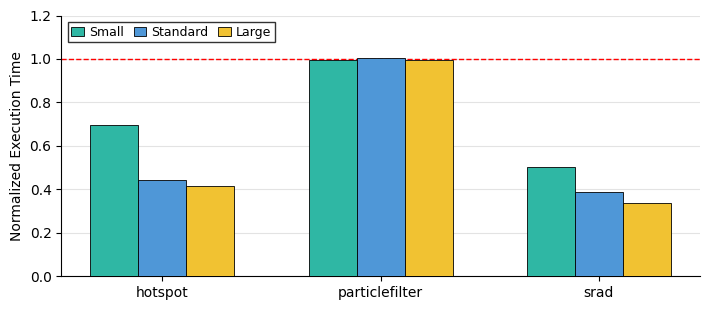

Saved: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/figures/scaled_figure_10_rodinia_normalized_runtime.png


In [50]:
# Generate scaled Figure 10-style Rodinia plot.

def normalize_size_label(x):
    x = str(x).strip().lower()
    if x.startswith("small"):
        return "Small"
    if x.startswith("standard"):
        return "Standard"
    if x.startswith("large"):
        return "Large"
    return str(x)

fig10_df = rodinia_summary[rodinia_summary["threads"] == MAIN_PLOT_THREADS].copy()
fig10_df["size"] = fig10_df["size"].apply(normalize_size_label)

fig10_df = (
    fig10_df
    .groupby(["kernel", "size"], as_index=False)
    .agg({"normalized_runtime": "median"})
)

kernel_order = ["hotspot", "particlefilter", "srad"]
size_order = ["Small", "Standard", "Large"]

fig10_df["kernel"] = pd.Categorical(fig10_df["kernel"], categories=kernel_order, ordered=True)
fig10_df["size"] = pd.Categorical(fig10_df["size"], categories=size_order, ordered=True)

pivot_df = (
    fig10_df
    .pivot(index="kernel", columns="size", values="normalized_runtime")
    .reindex(kernel_order)
)

size_colors = {
    "Small": "#2fb7a4",
    "Standard": "#4f97d7",
    "Large": "#f1c232",
}

fig, ax = plt.subplots(figsize=(7.2, 3.2))

x = np.arange(len(kernel_order))
bar_width = 0.22
y_clip = max(1.2, float(np.nanmax(pivot_df.values)) * 1.08)

for i, size_name in enumerate(size_order):
    values = pivot_df[size_name].values
    positions = x + (i - 1) * bar_width

    ax.bar(
        positions,
        values,
        width=bar_width,
        color=size_colors[size_name],
        edgecolor="black",
        linewidth=0.6,
        label=size_name,
        zorder=3,
    )

ax.axhline(1.0, color="red", linestyle="--", linewidth=1.0, zorder=2)

ax.set_ylim(0, y_clip)
ax.set_ylabel("Normalized Execution Time")
ax.set_xticks(x)
ax.set_xticklabels(kernel_order)
ax.grid(axis="y", linestyle="-", alpha=0.35, zorder=0)
ax.set_axisbelow(True)

ax.legend(
    loc="upper left",
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    fontsize=9,
    borderpad=0.3,
    handlelength=1.0,
    handletextpad=0.4,
    columnspacing=0.8,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig10_path = FIGURES_DIR / "scaled_figure_10_rodinia_normalized_runtime.png"
plt.savefig(fig10_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig10_path)

## Scaled Figure 7: PolyBench Normalized Runtime

This figure follows the layout style of the original HYPERF PolyBench figure:

- three stacked panels for Small, Standard, and Large input sizes
- benchmark ordering similar to the paper
- red dashed baseline at normalized runtime `1.0`
- y-axis: optimized runtime divided by baseline runtime

This artifact reports one optimized variant, labeled **Optimized**, rather than Pluto/Polly/HYPERF because this scaled artifact does not run the full Pluto, Polly, and HYPERF toolchains.

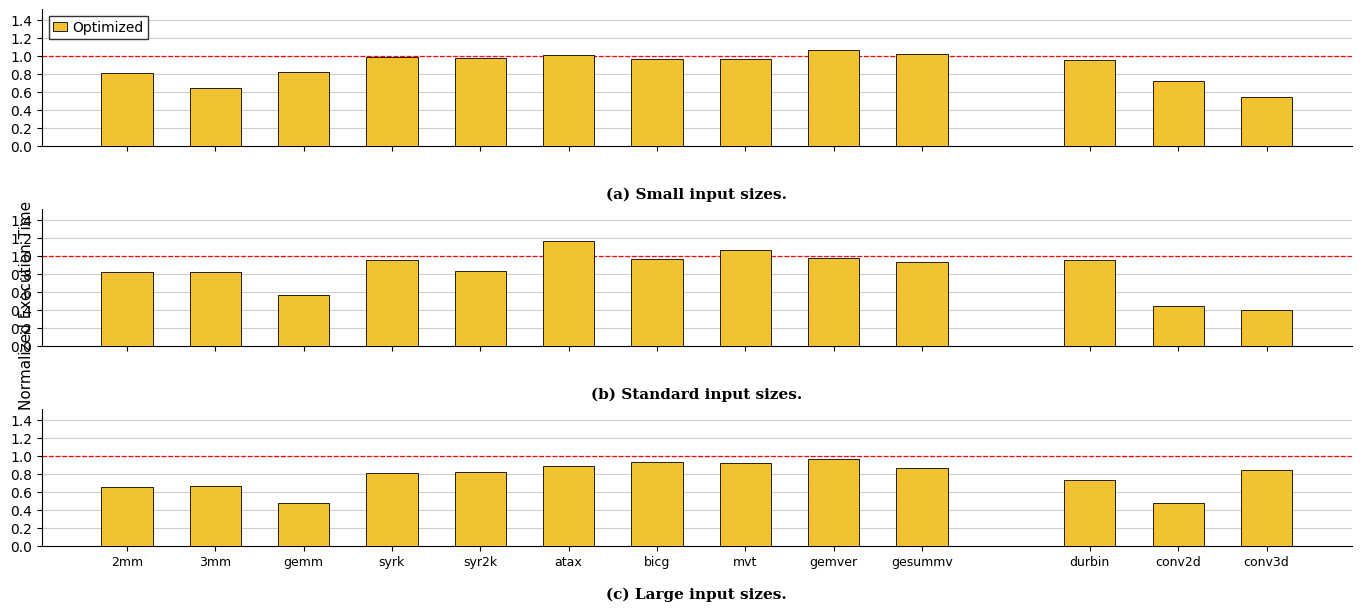

Saved: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/figures/scaled_figure_7_polybench_normalized_runtime.png


In [51]:
# Generate scaled Figure 7-style PolyBench plot.

fig7_df = polybench_summary[polybench_summary["threads"] == MAIN_PLOT_THREADS].copy()
fig7_df["size"] = fig7_df["size"].apply(normalize_size_label)

fig7_df = (
    fig7_df
    .groupby(["kernel", "size"], as_index=False)
    .agg({"normalized_runtime": "median"})
)

left_group = [
    "2mm", "3mm", "gemm", "syrk", "syr2k",
    "atax", "bicg", "mvt", "gemver", "gesummv",
]
right_group = ["durbin", "conv2d", "conv3d"]

available = set(fig7_df["kernel"].unique())
left_group = [k for k in left_group if k in available]
right_group = [k for k in right_group if k in available]
benchmark_order = left_group + right_group

# Create x positions with a paper-like gap between benchmark groups.
x_positions = {}
x_pos = 0.0

for kernel in left_group:
    x_positions[kernel] = x_pos
    x_pos += 1.0

x_pos += 0.9

for kernel in right_group:
    x_positions[kernel] = x_pos
    x_pos += 1.0

size_order = ["Small", "Standard", "Large"]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(13.5, 6.0),
    sharex=True,
    constrained_layout=True,
)

optimized_color = "#f1c232"
y_clip = 1.4

panel_titles = {
    "Small": "(a) Small input sizes.",
    "Standard": "(b) Standard input sizes.",
    "Large": "(c) Large input sizes.",
}

for ax, size_name in zip(axes, size_order):
    panel_df = fig7_df[fig7_df["size"] == size_name].copy()

    values_by_kernel = {
        row["kernel"]: row["normalized_runtime"]
        for _, row in panel_df.iterrows()
    }

    x_vals = [x_positions[k] for k in benchmark_order]
    y_vals = np.array([values_by_kernel.get(k, np.nan) for k in benchmark_order], dtype=float)

    clipped_vals = np.minimum(y_vals, y_clip)

    bars = ax.bar(
        x_vals,
        clipped_vals,
        width=0.58,
        color=optimized_color,
        edgecolor="black",
        linewidth=0.6,
        label="Optimized",
        zorder=3,
    )

    # Annotate values clipped above the visible y-range.
    for bar, actual_value in zip(bars, y_vals):
        if pd.notna(actual_value) and actual_value > y_clip:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y_clip + 0.03,
                f"{actual_value:.1f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.axhline(1.0, color="red", linestyle="--", linewidth=0.9, zorder=2)
    ax.set_ylim(0, y_clip + 0.12)
    ax.set_yticks(np.arange(0, 1.41, 0.2))
    ax.grid(axis="y", color="0.75", linestyle="-", linewidth=0.8, alpha=0.75, zorder=0)
    ax.set_axisbelow(True)

    ax.text(
        0.5,
        -0.30,
        panel_titles[size_name],
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=11,
        fontweight="bold",
        family="serif",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    edgecolor="black",
    fontsize=10,
    borderpad=0.3,
    handlelength=1.0,
    handletextpad=0.4,
)

axes[-1].set_xticks([x_positions[k] for k in benchmark_order])
axes[-1].set_xticklabels(benchmark_order, fontsize=9)

fig.text(
    0.01,
    0.5,
    "Normalized Execution Time",
    rotation=90,
    va="center",
    fontsize=11,
)

fig7_path = FIGURES_DIR / "scaled_figure_7_polybench_normalized_runtime.png"
plt.savefig(fig7_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig7_path)

## Improved Scaled Figure 7: PolyBench Normalized Runtime

This figure reproduces the visual structure of Figure 7 from the HYPERF paper as closely as possible using the data generated by this artifact.

Unlike the original paper, this scaled reproduction includes only one optimized variant, labeled **Optimized**, rather than separate Pluto, Polly, and HYPERF bars. The figure still preserves the three-panel layout for Small, Standard, and Large input sizes and reports normalized execution time relative to the baseline.

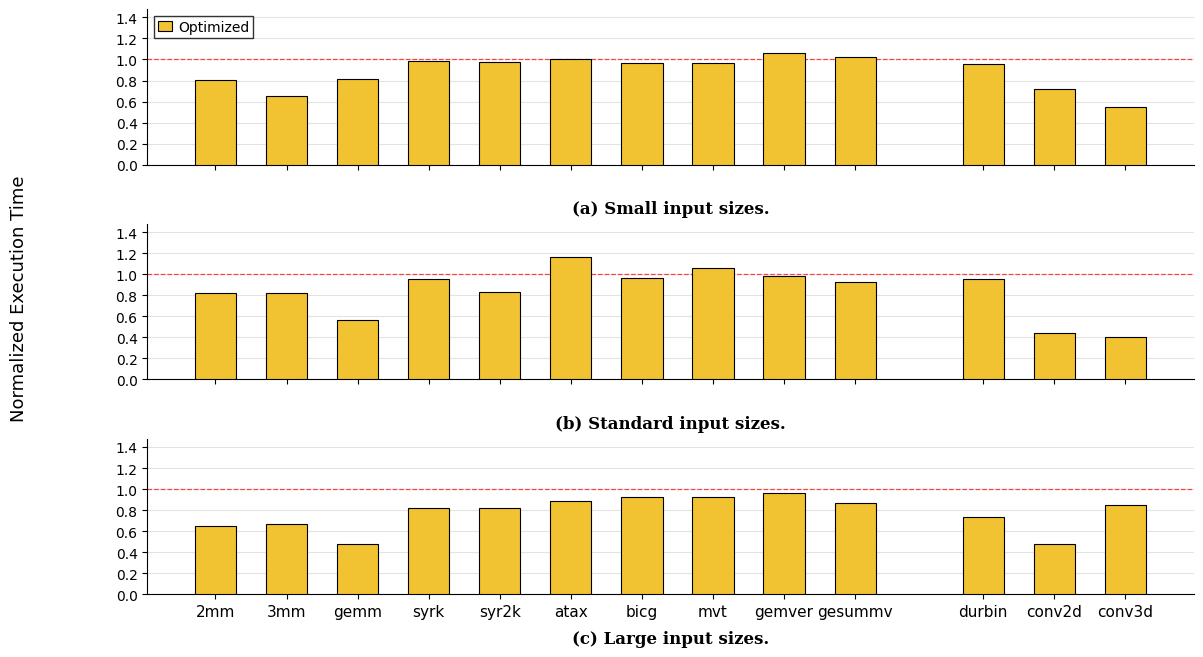

Saved: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/figures/scaled_figure_7_polybench_normalized_runtime_improved.png


In [52]:
# Generate an improved Figure 7-style PolyBench plot using the artifact's data.
# This version keeps the paper-style three-panel layout, group spacing, and baseline line,
# but it uses only one optimized method because this artifact does not run Pluto and Polly.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the processed PolyBench summary.
fig7_df = pd.read_csv(RESULTS_DIR / "scaled_figure_7_polybench_summary.csv").copy()

# Normalize size labels to match the panel captions.
def normalize_size_label(x):
    x = str(x).strip().lower()
    if x.startswith("small"):
        return "Small"
    if x.startswith("standard"):
        return "Standard"
    if x.startswith("large"):
        return "Large"
    return str(x)

fig7_df["size"] = fig7_df["size"].apply(normalize_size_label)

# Use the largest available thread count for the final paper-style figure.
main_threads = int(fig7_df["threads"].max())
fig7_df = fig7_df[fig7_df["threads"] == main_threads].copy()

# Aggregate in case there are repeated rows.
fig7_df = (
    fig7_df
    .groupby(["kernel", "size"], as_index=False)
    .agg({"normalized_runtime": "median"})
)

# Match the benchmark ordering used in the paper as closely as possible.
left_group = [
    "2mm", "3mm", "gemm", "syrk", "syr2k",
    "atax", "bicg", "mvt", "gemver", "gesummv",
]
right_group = ["durbin", "conv2d", "conv3d"]

available = set(fig7_df["kernel"].unique())
left_group = [k for k in left_group if k in available]
right_group = [k for k in right_group if k in available]
benchmark_order = left_group + right_group

# Build x positions with a visible gap between the two benchmark groups.
x_positions = {}
x = 0.0

for kernel in left_group:
    x_positions[kernel] = x
    x += 1.0

# Add a small visual gap before the last three kernels.
x += 0.8

for kernel in right_group:
    x_positions[kernel] = x
    x += 1.0

# Define the panel order.
size_order = ["Small", "Standard", "Large"]

# Create the figure with three stacked panels.
fig, axes = plt.subplots(
    3, 1,
    figsize=(13.5, 7.6),
    sharex=True,
    gridspec_kw={"hspace": 0.38}
)

# Paper-like style choices.
bar_color = "#f1c232"
edge_color = "black"
y_max = 1.4
panel_titles = {
    "Small": "(a) Small input sizes.",
    "Standard": "(b) Standard input sizes.",
    "Large": "(c) Large input sizes.",
}

for ax, size_name in zip(axes, size_order):
    panel_df = fig7_df[fig7_df["size"] == size_name].copy()

    # Build a kernel -> normalized runtime mapping.
    val_map = {
        row["kernel"]: row["normalized_runtime"]
        for _, row in panel_df.iterrows()
    }

    x_vals = [x_positions[k] for k in benchmark_order]
    y_vals = np.array([val_map.get(k, np.nan) for k in benchmark_order], dtype=float)

    # Clip bars to keep the plot readable, and annotate if values exceed the visible range.
    clipped = np.minimum(y_vals, y_max)

    bars = ax.bar(
        x_vals,
        clipped,
        width=0.58,
        color=bar_color,
        edgecolor=edge_color,
        linewidth=0.8,
        label="Optimized",
        zorder=3,
    )

    # Add the normalized baseline line.
    ax.axhline(1.0, color="red", linestyle="--", linewidth=0.9, alpha=0.7, zorder=2)

    # Annotate values that exceed the visible limit.
    for bar, actual in zip(bars, y_vals):
        if pd.notna(actual) and actual > y_max:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y_max + 0.03,
                f"{actual:.1f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    # Set panel styling.
    ax.set_ylim(0, y_max + 0.08)
    ax.set_yticks(np.arange(0, 1.41, 0.2))
    ax.grid(axis="y", linestyle="-", linewidth=0.8, alpha=0.35, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Put the panel caption beneath each subplot, similar to the paper.
    ax.text(
        0.5,
        -0.23,
        panel_titles[size_name],
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold",
        family="serif",
    )

# Show legend only once in the first panel.
axes[0].legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    edgecolor="black",
    fontsize=10,
    borderpad=0.3,
    handlelength=1.0,
    handletextpad=0.4,
)

# Add x tick labels only to the bottom panel.
axes[-1].set_xticks([x_positions[k] for k in benchmark_order])
axes[-1].set_xticklabels(benchmark_order, fontsize=11)

# Add one shared y-axis label for the whole figure.
fig.text(
    0.03,
    0.5,
    "Normalized Execution Time",
    rotation=90,
    va="center",
    ha="center",
    fontsize=13,
)

# Save and display the improved figure.
fig7_path = FIGURES_DIR / "scaled_figure_7_polybench_normalized_runtime_improved.png"
plt.savefig(fig7_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", fig7_path)

## Scaled Figure 11: Mini Tuning Convergence

The original HYPERF paper reports autotuning efficiency for `3mm` and `syrk`, plotting the best execution time found so far over tuning time. This artifact generates a scaled version using the local search over compiler/runtime variants collected during the experiment.

This is not the full TVM-HPC/ytopt/OpenTuner tuning process from the paper; it is a smaller convergence-style reproduction using this artifact’s available variants.

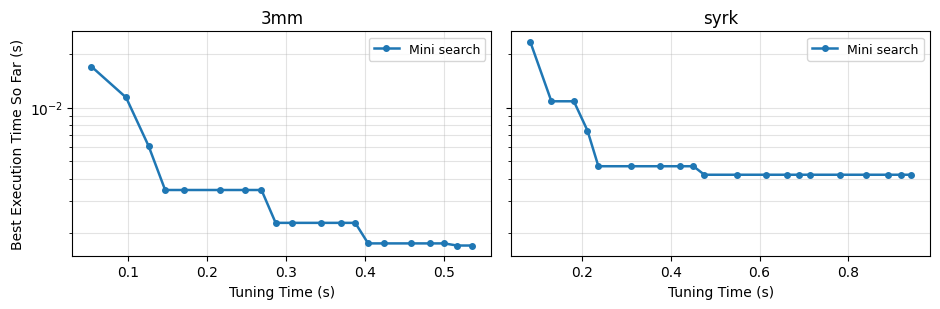

Saved: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/figures/scaled_figure_11_mini_tuning_convergence.png


In [53]:
# Generate scaled Figure 11-style tuning convergence plot.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tuning_trace = pd.read_csv(RESULTS_DIR / "scaled_hyperf_tuning_trace.csv").copy()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)

kernel_order = ["3mm", "syrk"]

for ax, kernel in zip(axes, kernel_order):
    kdf = tuning_trace[tuning_trace["kernel"] == kernel].copy()
    kdf = kdf.sort_values("elapsed_tuning_time_sec")

    ax.plot(
        kdf["elapsed_tuning_time_sec"],
        kdf["best_runtime_so_far_sec"],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label="Mini search",
    )

    ax.set_title(kernel)
    ax.set_xlabel("Tuning Time (s)")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="-", alpha=0.35)
    ax.legend(frameon=True, fontsize=9)

axes[0].set_ylabel("Best Execution Time So Far (s)")

plt.tight_layout()

fig11_path = FIGURES_DIR / "scaled_figure_11_mini_tuning_convergence.png"
plt.savefig(fig11_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", fig11_path)

## Generate Summary Tables

The next cell writes CSV tables summarizing:

1. benchmark coverage;
2. best normalized runtime per kernel;
3. environment and artifact metadata.

These tables help reviewers understand what was reproduced and what was scaled.

In [54]:
# Generate benchmark coverage and runtime summary tables.

summary = pd.read_csv(RESULTS_DIR / "scaled_hyperf_normalized_summary.csv").copy()

# Benchmark coverage table.
coverage_rows = []

for family, group_df in summary.groupby("family"):
    for kernel in sorted(group_df["kernel"].unique()):
        coverage_rows.append(
            {
                "family": family,
                "kernel": kernel,
                "sizes": ", ".join(sorted(group_df[group_df["kernel"] == kernel]["size"].unique())),
                "thread_counts": ", ".join(str(x) for x in sorted(group_df[group_df["kernel"] == kernel]["threads"].unique())),
                "artifact_scope": "scaled C/OpenMP kernel",
            }
        )

coverage_df = pd.DataFrame(coverage_rows)
coverage_path = RESULTS_DIR / "benchmark_coverage_table.csv"
coverage_df.to_csv(coverage_path, index=False)

# Best runtime summary table.
best_rows = []

for (family, kernel), group in summary.groupby(["family", "kernel"]):
    best = group.loc[group["normalized_runtime"].idxmin()]

    best_rows.append(
        {
            "family": family,
            "kernel": kernel,
            "best_size": best["size"],
            "best_threads": int(best["threads"]),
            "baseline_runtime_sec": best["median_runtime_sec_baseline"],
            "optimized_runtime_sec": best["median_runtime_sec_optimized"],
            "best_normalized_runtime": best["normalized_runtime"],
            "speedup_vs_baseline": 1.0 / best["normalized_runtime"] if best["normalized_runtime"] > 0 else np.nan,
        }
    )

best_df = pd.DataFrame(best_rows)
best_path = RESULTS_DIR / "best_runtime_summary_table.csv"
best_df.to_csv(best_path, index=False)

# Environment/artifact summary table.
environment_summary = {
    "paper": "HYPERF: End-to-End Autotuning Framework for High-Performance Computing",
    "artifact_type": "scaled reproduction",
    "site": SITE,
    "server_name": SERVER_NAME,
    "node_type": NODE_TYPE,
    "floating_ip": FLOATING_IP,
    "remote_workdir": REMOTE_WORKDIR,
    "main_plot_threads": int(summary["threads"].max()),
    "polybench_kernel_count": int(summary[summary["family"] == "polybench_style"]["kernel"].nunique()),
    "rodinia_kernel_count": int(summary[summary["family"] == "rodinia_style"]["kernel"].nunique()),
}

environment_df = pd.DataFrame(
    [{"field": key, "value": value} for key, value in environment_summary.items()]
)

environment_path = RESULTS_DIR / "environment_summary_table.csv"
environment_df.to_csv(environment_path, index=False)

print("Saved:", coverage_path)
print("Saved:", best_path)
print("Saved:", environment_path)

print("\nBenchmark coverage preview:")
display(coverage_df.head(20))

print("\nBest runtime summary preview:")
display(best_df.head(20))

print("\nEnvironment summary:")
display(environment_df)

Saved: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/results/benchmark_coverage_table.csv
Saved: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/results/best_runtime_summary_table.csv
Saved: /work/hpdc25-hyperf-reproduction-43885ef4062be13bcdb4b7d295f1a48cff2f6983/results/environment_summary_table.csv

Benchmark coverage preview:


,family,kernel,sizes,thread_counts,artifact_scope
0,polybench_style,2mm,"large, small, standard","1, 2, 4, 8, 16",scaled C/OpenMP kernel
1,polybench_style,3mm,"large, small, standard","1, 2, 4, 8, 16",scaled C/OpenMP kernel
2,polybench_style,atax,"large, small, standard","1, 2, 4, 8, 16",scaled C/OpenMP kernel
3,polybench_style,bicg,"large, small, standard","1, 2, 4, 8, 16",scaled C/OpenMP kernel
4,polybench_style,conv2d,"large, small, standard","1, 2, 4, 8, 16",scaled C/OpenMP kernel
5,polybench_style,conv3d,"large, small, standard","1, 2, 4, 8, 16",scaled C/OpenMP kernel
6,polybench_style,durbin,"large, small, standard","1, 2, 4, 8, 16",scaled C/OpenMP kernel
7,polybench_style,gemm,"large, small, standard","1, 2, 4, 8, 16",scaled C/OpenMP kernel
8,polybench_style,gemver,"large, small, standard","1, 2, 4, 8, 16",scaled C/OpenMP kernel
9,polybench_style,gesummv,"large, small, standard","1, 2, 4, 8, 16",scaled C/OpenMP kernel



Best runtime summary preview:


,family,kernel,best_size,best_threads,baseline_runtime_sec,optimized_runtime_sec,best_normalized_runtime,speedup_vs_baseline
0,polybench_style,2mm,standard,1,0.017012,0.005880,0.345638,2.893197
1,polybench_style,3mm,small,2,0.001372,0.000504,0.367347,2.722222
2,polybench_style,atax,standard,4,0.000212,0.000163,0.768868,1.300613
3,polybench_style,bicg,standard,4,0.000210,0.000166,0.790476,1.265060
4,polybench_style,conv2d,standard,4,0.005721,0.002288,0.399930,2.500437
5,polybench_style,conv3d,standard,16,0.013987,0.005614,0.401373,2.491450
6,polybench_style,durbin,large,16,0.012983,0.009492,0.731110,1.367783
7,polybench_style,gemm,standard,1,0.026413,0.007890,0.298717,3.347655
8,polybench_style,gemver,standard,4,0.000211,0.000165,0.781991,1.278788
9,polybench_style,gesummv,large,16,0.000459,0.000396,0.862745,1.159091



Environment summary:


,field,value
0,paper,HYPERF: End-to-End Autotuning Framework for Hi...
1,artifact_type,scaled reproduction
2,site,CHI@UC
3,server_name,hpdc25-hyperf-node
4,node_type,compute_skylake
5,floating_ip,192.5.86.159
6,remote_workdir,/home/cc/hpdc25-hyperf-reproduction
7,main_plot_threads,16
8,polybench_kernel_count,13
9,rodinia_kernel_count,3


## Reproduction Outputs

The artifact generated the following main outputs:

- `figures/scaled_figure_7_polybench_normalized_runtime_improved.png`
- `figures/scaled_figure_10_rodinia_normalized_runtime.png`
- `figures/scaled_figure_11_mini_tuning_convergence.png`
- `results/scaled_hyperf_raw_results.csv`
- `results/scaled_hyperf_normalized_summary.csv`
- `results/scaled_hyperf_tuning_trace.csv`
- `results/benchmark_coverage_table.csv`
- `results/best_runtime_summary_table.csv`
- `results/environment_summary_table.csv`

The generated results reproduce the structure of the paper’s PolyBench, Rodinia, and tuning-convergence evaluations in a scaled Chameleon artifact. The full paper evaluates HYPERF with the TVM-HPC autotuning stack, PolyBench-ACC/Rodinia benchmarks, and 256 autotuning iterations; this artifact uses scaled C/OpenMP kernels and a smaller compiler/runtime search.

## Conclusion

This notebook reproduces a scaled version of the HYPERF paper’s experimental workflow on Chameleon. It generates PolyBench-style, Rodinia-style, and mini tuning-convergence results, along with the corresponding figures and summary tables.

The generated results are broadly consistent with the main trends reported in the paper: the optimized variants generally reduce normalized execution time compared with the baseline, the Rodinia-style results follow the same normalized-runtime comparison structure, and the tuning-convergence plot shows how better configurations are found over time. Exact runtime values are not expected to match the paper because this artifact uses scaled C/OpenMP kernels, a different Chameleon machine, and a smaller compiler/runtime search instead of the full HYPERF TVM-HPC autotuning stack.

Overall, the artifact reproduces the paper’s key evaluation pattern: run baseline and optimized benchmark variants, collect repeated runtime measurements, compute normalized execution time, and regenerate paper-style figures in a rerunnable notebook environment.
